# Imports

In [1]:
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

packages = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "mysql.connector": "mysql-connector-python",
    "optuna": "optuna",
}

for import_name, pip_name in packages.items():
    try:
        __import__(import_name)
    except ImportError:
        install(pip_name)


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

# Données et base de données
import pandas as pd
import numpy as np
import mysql.connector

# Prétraitement
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Modèles
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Évaluation
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Tuning
import optuna

# Visualisation
import matplotlib.pyplot as plt

# Warnings
import warnings
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")


#seed pour avoir les mêmes résultats même si on fait du "random". Sinon nos analyses changent tout le temps avec optuna qui trouve des hyperparamètres différents
import random
seed = 42
random.seed(seed)
np.random.seed(seed)

c:\Users\beaul\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Nettoyage et préparation des données

## Connexion à la DB

In [2]:
connexion = mysql.connector.connect(
    host     = 'localhost',
    user     = 'root',
    password = '',
    database = 'gamesale'
)

## Création des dataframe

In [3]:
# Table principale
df = pd.read_sql("""
    SELECT
        id_jeu,
        nom_jeu,
        age_requis,
        nb_succes,
        nb_avis_pos,
        nb_avis_neg,
        temps_jeu_moyen,
        prix,
        ventes_Global
    FROM jeux
""", connexion)

# Conversion ventes (virgule/point)
df['ventes_Global'] = df['ventes_Global'].str.replace(',', '.').astype(float)

# Genre (un seul par jeu, on prend le premier)
df_genre = pd.read_sql("""
    SELECT id_jeu, genre
    FROM genre
    GROUP BY id_jeu
""", connexion)

# Éditeur (un seul par jeu)
df_edit = pd.read_sql("""
    SELECT id_jeu, id_editeur
    FROM editeur
    GROUP BY id_jeu
""", connexion)

# Développeur (un seul par jeu)
df_dev = pd.read_sql("""
    SELECT id_jeu, id_developpeur
    FROM developpeur
    GROUP BY id_jeu
""", connexion)

# OS (colonnes binaires 0/1)
df_os = pd.read_sql("""
    SELECT
        id_jeu,
        MAX(CASE WHEN id_os = 1 THEN 1 ELSE 0 END) AS os_windows,
        MAX(CASE WHEN id_os = 2 THEN 1 ELSE 0 END) AS os_mac,
        MAX(CASE WHEN id_os = 3 THEN 1 ELSE 0 END) AS os_linux
    FROM a_os
    GROUP BY id_jeu
""", connexion)

# Catégories (colonnes binaires 0/1)
df_cat = pd.read_sql("""
    SELECT
        id_jeu,
        MAX(CASE WHEN id_cat = '1'  THEN 1 ELSE 0 END) AS cat_multi,
        MAX(CASE WHEN id_cat = '2'  THEN 1 ELSE 0 END) AS cat_online,
        MAX(CASE WHEN id_cat = '4'  THEN 1 ELSE 0 END) AS cat_vac,
        MAX(CASE WHEN id_cat = '5'  THEN 1 ELSE 0 END) AS cat_solo,
        MAX(CASE WHEN id_cat = '6'  THEN 1 ELSE 0 END) AS cat_cloud,
        MAX(CASE WHEN id_cat = '7'  THEN 1 ELSE 0 END) AS cat_achiev,
        MAX(CASE WHEN id_cat = '8'  THEN 1 ELSE 0 END) AS cat_cards,
        MAX(CASE WHEN id_cat = '10' THEN 1 ELSE 0 END) AS cat_ctrl,
        MAX(CASE WHEN id_cat = '22' THEN 1 ELSE 0 END) AS cat_workshop
    FROM a_categorie
    GROUP BY id_jeu
""", connexion)

# Nombre de tags par jeu
curseur = connexion.cursor()
curseur.execute("SELECT * FROM a_tag LIMIT 1")
curseur.fetchall()
toutes_cols   = [description[0] for description in curseur.description]
colonnes_tags = toutes_cols[1:]
somme_tags    = ' + '.join([f'`{col}`' for col in colonnes_tags])

df_tags = pd.read_sql(f"""
    SELECT id_jeu, ({somme_tags}) AS nb_tags
    FROM a_tag
""", connexion)

connexion.close()

## Fusion des dataframe

In [4]:
df = df.merge(df_genre, on='id_jeu', how='left')
df = df.merge(df_edit,  on='id_jeu', how='left')
df = df.merge(df_dev,   on='id_jeu', how='left')
df = df.merge(df_os,    on='id_jeu', how='left')
df = df.merge(df_cat,   on='id_jeu', how='left')
df = df.merge(df_tags,  on='id_jeu', how='left')

print(f"Après fusion : {len(df)} jeux, {len(df.columns)} colonnes")

Après fusion : 780 jeux, 25 colonnes


## Nettoyage des données

In [5]:
# Supprimer les lignes avec des NaN dans les colonnes essentielles
df = df.dropna(subset=['ventes_Global', 'age_requis', 'prix'])

# Remplir les NaN restants
df['id_editeur']        = df['id_editeur'].fillna(-1).astype(int)
df['id_developpeur']    = df['id_developpeur'].fillna(-1).astype(int)
df['nb_tags']           = df['nb_tags'].fillna(0)
df = df.fillna(0)

print(len(df['id_editeur'].unique()))
print(len(df['id_editeur'].unique()))

print(df['genre'].unique())
print(df['id_editeur'].unique())
print(df['nb_tags'].unique())

print(f"Après nettoyage NaN : {len(df)} jeux")

225
225
['Action' 'Shooter' 'Role-Playing' 'Simulation' 'Fighting' 'Adventure'
 'Racing' 'Misc' 'Platform' 'Strategy' 'Sports' 'Puzzle']
[168   8 185  27  66 124 207  39 211 215  41 117 133 125   4  56 109  60
 174  51  33  24 196 140 145  16 192  98  28  75 205  50 164 102  25 147
  46 119  43 111  80 191 180  61 217   5 128 155  21 158 160  94 161 169
 203 131 186  91 222 104 116  86  54 173 139 144 118 127 184  74 188  93
 156 138 220 153  57 223 165  10 122  73 183 110  52 157 134  40 136 108
 193 103 107 148  44  82  69  45  15 130 137  48  29 218 132  77  53 141
  11  99  70 200 121 199 151 149   7  87 182 206 194  68 197 195  30  72
 210  14  71  79 181 115 152 172 201 214 106  22  64 179 177 171  18  58
 129  95 170 112 126 221 204  32 135   6 166 100  83 105  88  37 224  81
 120   2  17 219 154  35  49 175  78  67 123   3  89   9  84 187 213 198
 208  26 101  12  31  63 162  96  42  34 216 146 142  55  20 150  19 178
 190 212  59 202  13  92 209  23  97 189 225  65   1 114 176

## Suppression des valeurs aberrantes (quantile>0.9)
On les supprime car on a quelques jeux qui ont énormément bien marché (ex: GTA) mais c'est pas ce qui est le plus commun, ce qui tire la moyenne vers le haut, et donc nos modèles ont du mal à prédire les jeux "normaux". Ces valeurs aberrantes dégradent les performances de nos modèles sur les cas courants de jeux vidéo.

In [6]:
seuil_90 = df['ventes_Global'].quantile(0.90)
df = df[df['ventes_Global'] <= seuil_90]

print(f"Après suppression du top 10% (seuil={seuil_90:.2f}M) : {len(df)} jeux")

Après suppression du top 10% (seuil=3.80M) : 702 jeux


## Encodage des variables catégorielles non encodées (genre)

In [7]:
le_genre = LabelEncoder() #chaque catégorie est remplacée par un nombre entier
df['genre_enc'] = le_genre.fit_transform(df['genre'])

## Variables explicatives

In [8]:
variables_explicatives = [
    'age_requis',
    'nb_succes',
    'nb_avis_pos',
    'nb_avis_neg',
    'temps_jeu_moyen',
    'prix',
    'genre_enc',
    'id_editeur',
    'id_developpeur',
    'os_windows',
    'os_mac',
    'os_linux',
    'cat_multi',
    'cat_online',
    'cat_vac',
    'cat_solo',
    'cat_cloud',
    'cat_achiev',
    'cat_cards',
    'cat_ctrl',
    'cat_workshop',
    'nb_tags',
]

X   = df[variables_explicatives]
y   = df['ventes_Global'].values     # ventes réelles (en millions)
y_log = np.log1p(y)                  # ventes log pour SVR

print(f"\nDataset final : {X.shape[0]} jeux, {X.shape[1]} features")
print(f"Ventes :\nmin: {y.min():.2f}M - max: {y.max():.2f}M - moyenne: {y.mean():.2f}M")
print(f"\nVariables explicatives utilisées :\n")
for f in variables_explicatives:
    print(f"  - {f}")


Dataset final : 702 jeux, 22 features
Ventes :
min: 0.01M - max: 3.79M - moyenne: 0.64M

Variables explicatives utilisées :

  - age_requis
  - nb_succes
  - nb_avis_pos
  - nb_avis_neg
  - temps_jeu_moyen
  - prix
  - genre_enc
  - id_editeur
  - id_developpeur
  - os_windows
  - os_mac
  - os_linux
  - cat_multi
  - cat_online
  - cat_vac
  - cat_solo
  - cat_cloud
  - cat_achiev
  - cat_cards
  - cat_ctrl
  - cat_workshop
  - nb_tags


# Tuning et entraînement des modèles

Fonction pour rechercher les hyperparamètres de nos modèles.

In [9]:
def objective(trial, model_name):
    """
    Fonction objectif pour Optuna.
    Définit l'espace de recherche des hyperparamètres des modèles gradient boosting, random forest ou svr,
    entraîne un modèle avec la combinaison proposée par Optuna,
    et retourne le R² moyen (négatif) en cross-validation 5-fold.
    """
    if model_name == "gradient_boosting":
        param_space = {
            'n_estimators':      trial.suggest_int('n_estimators', 50, 500, step=50),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth':         trial.suggest_int('max_depth', 2, 8),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        }
        model_trial = GradientBoostingRegressor(**param_space, random_state=42)

    elif model_name == "random_forest":
        param_space = {
            'n_estimators':      trial.suggest_int('n_estimators', 50, 500, step=50),
            'max_depth':         trial.suggest_int('max_depth', 2, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        }
        model_trial = RandomForestRegressor(**param_space, random_state=42)

    elif model_name == "svr":
        param_space = {
            'C':       trial.suggest_float('C', 0.1, 100, log=True),
            'epsilon': trial.suggest_float('epsilon', 0.01, 1.0, log=True),
            'kernel':  trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly']),
            'gamma':   trial.suggest_categorical('gamma', ['scale', 'auto']),
        }
        model_trial = SVR(**param_space)
        scores = cross_val_score(model_trial,X,y_log,cv=3,scoring='r2',n_jobs=-1) #on fait en y_log pour svr, on met le cv à 5 car svr a une complexité quadratique
        return -scores.mean()

    # Cross-validation sur le train set - métrique : R²
    scores = cross_val_score(model_trial, X, y, cv=5, scoring='r2', n_jobs=-1)
    return -scores.mean() # on minimise donc on inverse le R²

## Random Forest

### Tuning
Recherche des meilleurs hyperparamètres

In [10]:
study_rf = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_rf.optimize(lambda trial: objective(trial, "random_forest"), n_trials=100, show_progress_bar=True,n_jobs=-1)

[I 2026-04-11 11:52:51,166] A new study created in memory with name: no-name-c9e5b77e-ff3d-4b79-b884-abd9c64d01ee
Best trial: 58. Best value: 294.647: 100%|██████████| 100/100 [00:10<00:00,  9.43it/s]


Malgré les seed, les résultats variaient un peu à chaque lancement car n_jobs=-1 permet de faire plusieurs essais en parallèle afin d'aller plus vite. Nous avons donc du choisir entre soit :
- mettre n_jobs=1 pour assurer la stabilité et faire les tests un à un, ce qui serait long (le chunck d'évaluation par LOOCV en dessous prend 4 minutes avec un bon processeur, et ce 8 fois dans ce rapport)
- faire tourner le tuning une seule fois sur notre machine, puis enregistrer les hyperparamètres donnés par optuna en dur dans un dictionnaire, et remettre n_jobs=-1 pour la rapidité

Nous avons donc décidé, puisque nous n'avons pas les machines nécessaires pour bien faire tourner ce jupyter, d'enregistrer les hyperparamètres en dur afin d'assurer la reproductiblité de nos expériences et entraînements, et ainsi que nos analyses soient cohérentes avec les résultats affichés.

In [11]:
best_params_rf = {
    'n_estimators': 50,
    'max_depth': 12,
    'min_samples_split': 6,
    'min_samples_leaf': 1,
    'max_features': 'log2'
}

model = RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1)
print(f"Meilleurs hyperparamètres : {best_params_rf}")

Meilleurs hyperparamètres : {'n_estimators': 50, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2'}


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [12]:
# LOOCV = Leave One Out Cross Validation
# Principe : on a par exemple 100 jeux
#   - Tour 1  : on entraîne sur les jeux 2 à 100, on prédit le jeu 1
#   - Tour 2  : on entraîne sur les jeux 1 et 3 à 100, on prédit le jeu 2
#   - ...
#   - Tour 100 : on entraîne sur les jeux 1 à 99, on prédit le jeu 100
# À la fin, chaque jeu a été prédit exactement une fois, sans jamais
# avoir été utilisé pour l'entraînement de sa propre prédiction

loo = LeaveOneOut()

liste_valeurs_reelles=[]
liste_valeurs_predites=[]

#Boucle LOOCV
nombre_total_tours=len(X)
tour_actuel=0

# la fonction ci dessous a été entièrement toruvée sur internet, mais j'ai pris le temps de bien la comprendre.
for train_idx, test_idx in loo.split(X):
    # loo.split(X) génère à chaque tour :
    #   - train_idx : les indices des jeux utilisés pour l'entraînement
    #   - test_idx  : l'indice du jeu qu'on veut prédire (toujours 1 seul)
    tour_actuel=tour_actuel+1
    
     # On découpe X et y en données d'entraînement et de test
    X_train = X.iloc[train_idx]   # toutes les lignes sauf une
    X_test  = X.iloc[test_idx]    # la ligne qu'on veut prédire

    y_train = y[train_idx]   # les vraies ventes pour l'entraînement
    y_test  = y[test_idx]    # la vraie vente du jeu à prédire

        # ── Normalisation ──
    # On met toutes les features à la même échelle (moyenne=0, écart-type=1)

    scaler      = StandardScaler()
    X_train_normalise = scaler.fit_transform(X_train)  # calcule ET applique
    X_test_normalise  = scaler.transform(X_test)       # applique seulement


    #Entrainement
    # On entraîne le modèle (ici Random Forest qui est dans le chunk précédent) sur les données d'entraînement normalisées
    model.fit(X_train_normalise, y_train)

    #Prédiction 
    # On prédit les ventes du jeu de test
    # [0] car predict() retourne une liste, on veut juste le premier élément
    valeur_predite = model.predict(X_test_normalise)[0]
    valeur_reelle  = y_test[0]

    # On stocke les résultats
    liste_valeurs_predites.append(valeur_predite)
    liste_valeurs_reelles.append(valeur_reelle)

### Résultats

In [13]:
y_pred = np.array(liste_valeurs_predites)
y_true = np.array(liste_valeurs_reelles)


# RMSE = Root Mean Squared Error : erreur typique du modèle en millions d'exemplaires
rmse_rf = np.sqrt(mean_squared_error(y_true, y_pred))

# MAE = Mean Absolute Error : erreur absolue moyenne en millions d'exemplaires
mae_rf = mean_absolute_error(y_true, y_pred)

# R² = coefficient de détermination : entre 0 et 1, indique la part de variance expliquée par le modèle
r2_rf = r2_score(y_true, y_pred)

y_pred_rf =  y_pred.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - Random Forest")
print(f"  RMSE : {rmse_rf:.3f}M En moyenne le modèle se trompe de +-{rmse_rf:.2f} millions")
print(f"  MAE  : {mae_rf:.3f}M")
print(f"  R²   : {r2_rf:.3f}  Le modèle explique {r2_rf*100:.1f}% de la variance des ventes")


Résultats LOOCV - Random Forest
  RMSE : 0.757M En moyenne le modèle se trompe de +-0.76 millions
  MAE  : 0.547M
  R²   : 0.245  Le modèle explique 24.5% de la variance des ventes


## Gradient Boosting

### Tuning
Recherche des meilleurs hyperparamètres. On utilise optuna qui cherche automatiquement les meilleurs hyperparamètres. Il oriente intelligemment les essais vers les meilleures combinaisons en minimisant le RMSE.

In [14]:
study_gb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_gb.optimize(lambda trial: objective(trial, "gradient_boosting"), n_trials=100, show_progress_bar=True,n_jobs=-1)

Best trial: 94. Best value: 269.771: 100%|██████████| 100/100 [00:11<00:00,  9.08it/s]


In [15]:
best_params_gb = {
    'n_estimators': 300,
    'learning_rate': 0.021085345402470423,
    'max_depth': 2,
    'subsample': 0.844382925236584,
    'min_samples_split': 18,
    'min_samples_leaf': 4,
    'max_features': 'log2'
}

model = GradientBoostingRegressor(**best_params_gb, random_state=42)
print(f"Meilleurs hyperparamètres : {best_params_gb}")

Meilleurs hyperparamètres : {'n_estimators': 300, 'learning_rate': 0.021085345402470423, 'max_depth': 2, 'subsample': 0.844382925236584, 'min_samples_split': 18, 'min_samples_leaf': 4, 'max_features': 'log2'}


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [16]:
# LOOCV = Leave One Out Cross Validation
# Principe : on a par exemple 100 jeux
#   - Tour 1  : on entraîne sur les jeux 2 à 100, on prédit le jeu 1
#   - Tour 2  : on entraîne sur les jeux 1 et 3 à 100, on prédit le jeu 2
#   - ...
#   - Tour 100 : on entraîne sur les jeux 1 à 99, on prédit le jeu 100
# À la fin, chaque jeu a été prédit exactement une fois, sans jamais
# avoir été utilisé pour l'entraînement de sa propre prédiction

loo = LeaveOneOut()

liste_valeurs_reelles=[]
liste_valeurs_predites=[]

#Boucle LOOCV
nombre_total_tours=len(X)
tour_actuel=0

# la fonction ci dessous a été entièrement toruvée sur internet, mais j'ai pris le temps de bien la comprendre.
for train_idx, test_idx in loo.split(X):
    # loo.split(X) génère à chaque tour :
    #   - train_idx : les indices des jeux utilisés pour l'entraînement
    #   - test_idx  : l'indice du jeu qu'on veut prédire (toujours 1 seul)
    tour_actuel=tour_actuel+1
    
     # On découpe X et y en données d'entraînement et de test
    X_train = X.iloc[train_idx]   # toutes les lignes sauf une
    X_test  = X.iloc[test_idx]    # la ligne qu'on veut prédire

    y_train = y[train_idx]   # les vraies ventes pour l'entraînement
    y_test  = y[test_idx]    # la vraie vente du jeu à prédire

        # ── Normalisation ──
    # On met toutes les features à la même échelle (moyenne=0, écart-type=1)

    scaler      = StandardScaler()
    X_train_normalise = scaler.fit_transform(X_train)  # calcule ET applique
    X_test_normalise  = scaler.transform(X_test)       # applique seulement


    #Entrainement
    # On entraîne le modèle (ici Gradient Boosting qui est dans le chunk précédent) sur les données d'entraînement normalisées
    model.fit(X_train_normalise, y_train)

    #Prédiction 
    # On prédit les ventes du jeu de test
    # [0] car predict() retourne une liste, on veut juste le premier élément
    valeur_predite = model.predict(X_test_normalise)[0]
    valeur_reelle  = y_test[0]

    # On stocke les résultats
    liste_valeurs_predites.append(valeur_predite)
    liste_valeurs_reelles.append(valeur_reelle)

### Résultats

In [17]:
y_pred = np.array(liste_valeurs_predites)
y_true = np.array(liste_valeurs_reelles)


# RMSE = Root Mean Squared Error : erreur typique du modèle en millions d'exemplaires
rmse_gb = np.sqrt(mean_squared_error(y_true, y_pred))

# MAE = Mean Absolute Error : erreur absolue moyenne en millions d'exemplaires
mae_gb = mean_absolute_error(y_true, y_pred)

# R² = coefficient de détermination : entre 0 et 1, indique la part de variance expliquée par le modèle
r2_gb = r2_score(y_true, y_pred)

y_pred_gb =  y_pred.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - Gradient Boosting")
print(f"  RMSE : {rmse_gb:.3f}M En moyenne le modèle se trompe de +-{rmse_gb:.2f} millions")
print(f"  MAE  : {mae_gb:.3f}M")
print(f"  R²   : {r2_gb:.3f}  Le modèle explique {r2_gb*100:.1f}% de la variance des ventes")


Résultats LOOCV - Gradient Boosting
  RMSE : 0.755M En moyenne le modèle se trompe de +-0.76 millions
  MAE  : 0.546M
  R²   : 0.248  Le modèle explique 24.8% de la variance des ventes


## Support Vector Regression

Nous voulions coder un 3ème modèle de machine learning, le SVR, malheureusement ce dernier met trop de temps à tourner avec un loocv dû à sa complexité quadratique, même en testant des nombres d'essais et de folds de cross validation faibles. Nous vous montrons donc toutes les parties SVR dans le code en commentaire mais ne l'utiliserons pas.

### Tuning
Recherche des meilleurs hyperparamètres

In [18]:
# On utilise y_log pour l'entraînement du SVR (stabilise la distribution)
""" study_svr = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_svr.optimize(lambda trial: objective(trial, "svr"), n_trials=20, show_progress_bar=True,n_jobs=-1)
model = SVR(**study_svr.best_params)
print(f"Meilleurs hyperparamètres Optuna : {study_svr.best_params}") """

' study_svr = optuna.create_study(\n    direction=\'minimize\',\n    sampler=optuna.samplers.TPESampler(seed=42),\n    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)\n)\noptuna.logging.set_verbosity(optuna.logging.WARNING)\nstudy_svr.optimize(lambda trial: objective(trial, "svr"), n_trials=20, show_progress_bar=True,n_jobs=-1)\nmodel = SVR(**study_svr.best_params)\nprint(f"Meilleurs hyperparamètres Optuna : {study_svr.best_params}") '

### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [19]:
# LOOCV = Leave One Out Cross Validation
# Principe : on a par exemple 100 jeux
#   - Tour 1  : on entraîne sur les jeux 2 à 100, on prédit le jeu 1
#   - Tour 2  : on entraîne sur les jeux 1 et 3 à 100, on prédit le jeu 2
#   - ...
#   - Tour 100 : on entraîne sur les jeux 1 à 99, on prédit le jeu 100
# À la fin, chaque jeu a été prédit exactement une fois, sans jamais
# avoir été utilisé pour l'entraînement de sa propre prédiction
""" 
loo = LeaveOneOut()

liste_valeurs_reelles=[]
liste_valeurs_predites=[]

#Boucle LOOCV
nombre_total_tours=len(X)
tour_actuel=0

# la fonction ci dessous a été entièrement toruvée sur internet, mais j'ai pris le temps de bien la comprendre.
for train_idx, test_idx in loo.split(X):
    # loo.split(X) génère à chaque tour :
    #   - train_idx : les indices des jeux utilisés pour l'entraînement
    #   - test_idx  : l'indice du jeu qu'on veut prédire (toujours 1 seul)
    tour_actuel=tour_actuel+1
    
     # On découpe X et y en données d'entraînement et de test
    X_train = X.iloc[train_idx]   # toutes les lignes sauf une
    X_test  = X.iloc[test_idx]    # la ligne qu'on veut prédire

    y_train = y_log[train_idx]   # les ventes en log pour l'entraînement
    y_test  = y_log[test_idx]    # la vente du jeu à prédire en log

        # ── Normalisation ──
    # On met toutes les features à la même échelle (moyenne=0, écart-type=1)

    scaler      = StandardScaler()
    X_train_normalise = scaler.fit_transform(X_train)  # calcule ET applique
    X_test_normalise  = scaler.transform(X_test)       # applique seulement


    #Entrainement
    # On entraîne le modèle (ici SVR qui est dans le chunk précédent) sur les données d'entraînement normalisées
    model.fit(X_train_normalise, y_train)

    #Prédiction 
    # On prédit les ventes du jeu de test
    # [0] car predict() retourne une liste, on veut juste le premier élément
    valeur_predite = np.expm1(model.predict(X_test_normalise)[0]) #on retire le log
    valeur_reelle  = np.expm1(y_test[0]) #on retire le log

    # On stocke les résultats
    liste_valeurs_predites.append(valeur_predite)
    liste_valeurs_reelles.append(valeur_reelle) """

" \nloo = LeaveOneOut()\n\nliste_valeurs_reelles=[]\nliste_valeurs_predites=[]\n\n#Boucle LOOCV\nnombre_total_tours=len(X)\ntour_actuel=0\n\n# la fonction ci dessous a été entièrement toruvée sur internet, mais j'ai pris le temps de bien la comprendre.\nfor train_idx, test_idx in loo.split(X):\n    # loo.split(X) génère à chaque tour :\n    #   - train_idx : les indices des jeux utilisés pour l'entraînement\n    #   - test_idx  : l'indice du jeu qu'on veut prédire (toujours 1 seul)\n    tour_actuel=tour_actuel+1\n\n     # On découpe X et y en données d'entraînement et de test\n    X_train = X.iloc[train_idx]   # toutes les lignes sauf une\n    X_test  = X.iloc[test_idx]    # la ligne qu'on veut prédire\n\n    y_train = y_log[train_idx]   # les ventes en log pour l'entraînement\n    y_test  = y_log[test_idx]    # la vente du jeu à prédire en log\n\n        # ── Normalisation ──\n    # On met toutes les features à la même échelle (moyenne=0, écart-type=1)\n\n    scaler      = StandardSca

### Résultats

In [20]:
""" y_pred = np.array(liste_valeurs_predites)
y_true = np.array(liste_valeurs_reelles)


# RMSE = Root Mean Squared Error : erreur typique du modèle en millions d'exemplaires
rmse_svr = np.sqrt(mean_squared_error(y_true, y_pred))

# MAE = Mean Absolute Error : erreur absolue moyenne en millions d'exemplaires
mae_svr = mean_absolute_error(y_true, y_pred)

# R² = coefficient de détermination : entre 0 et 1, indique la part de variance expliquée par le modèle
r2_svr = r2_score(y_true, y_pred)

y_pred_svr =  y_pred.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - SVR")
print(f"  RMSE : {rmse_svr:.3f}M En moyenne le modèle se trompe de +-{rmse_svr:.2f} millions")
print(f"  MAE  : {mae_svr:.3f}M")
print(f"  R²   : {r2_svr:.3f}  Le modèle explique {r2_svr*100:.1f}% de la variance des ventes") """

' y_pred = np.array(liste_valeurs_predites)\ny_true = np.array(liste_valeurs_reelles)\n\n\n# RMSE = Root Mean Squared Error : erreur typique du modèle en millions d\'exemplaires\nrmse_svr = np.sqrt(mean_squared_error(y_true, y_pred))\n\n# MAE = Mean Absolute Error : erreur absolue moyenne en millions d\'exemplaires\nmae_svr = mean_absolute_error(y_true, y_pred)\n\n# R² = coefficient de détermination : entre 0 et 1, indique la part de variance expliquée par le modèle\nr2_svr = r2_score(y_true, y_pred)\n\ny_pred_svr =  y_pred.copy() #sauvegarde pour les graphiques\n\nprint(f"\nRésultats LOOCV - SVR")\nprint(f"  RMSE : {rmse_svr:.3f}M En moyenne le modèle se trompe de +-{rmse_svr:.2f} millions")\nprint(f"  MAE  : {mae_svr:.3f}M")\nprint(f"  R²   : {r2_svr:.3f}  Le modèle explique {r2_svr*100:.1f}% de la variance des ventes") '

# Comparaison des modèles

## Tableau récapitulatif

In [21]:
resultats = {
    'Modèle':             ['Random Forest', 'Gradient Boosting'],
    'RMSE (M)':           [rmse_rf, rmse_gb],
    'MAE (M)':            [mae_rf,  mae_gb],
    'R²':                 [r2_rf,   r2_gb],
}

df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values('RMSE (M)')
print(df_resultats.to_string(index=False))

           Modèle  RMSE (M)  MAE (M)       R²
Gradient Boosting  0.755431 0.546302 0.248063
    Random Forest  0.756838 0.547330 0.245260


## Comparaison RMSE et MAE

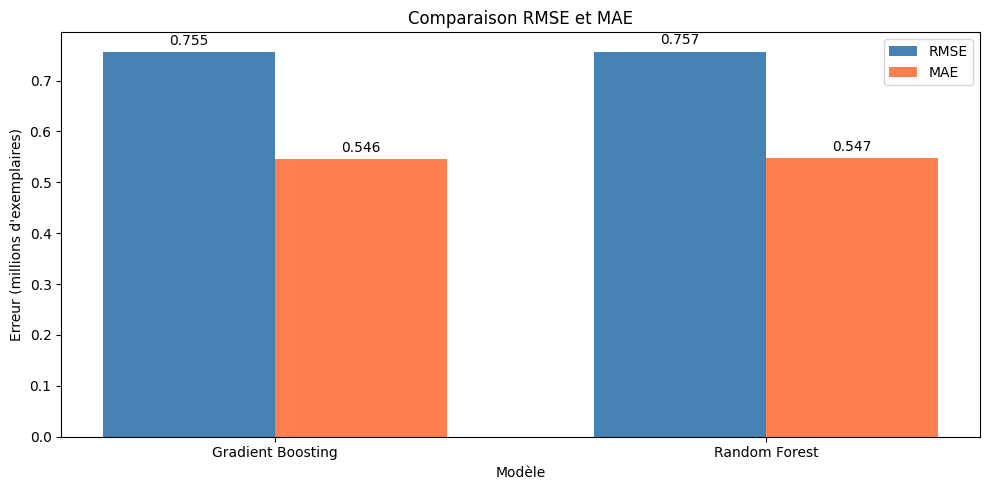

In [22]:
modeles = df_resultats['Modèle'].values
x = np.arange(len(modeles))
largeur = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
barres_rmse = ax.bar(x - largeur/2, df_resultats['RMSE (M)'], largeur, label='RMSE', color='steelblue')
barres_mae  = ax.bar(x + largeur/2, df_resultats['MAE (M)'],  largeur, label='MAE',  color='coral')

ax.set_xlabel('Modèle')
ax.set_ylabel('Erreur (millions d\'exemplaires)')
ax.set_title('Comparaison RMSE et MAE')
ax.set_xticks(x)
ax.set_xticklabels(modeles)
ax.legend()
ax.bar_label(barres_rmse, fmt='%.3f', padding=3)
ax.bar_label(barres_mae,  fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

### Analyse de la comparaison du RMSE et MAE
Ce graphique compare les **erreurs de prédiction** des deux modèles via le RMSE (root mean squared error) et le MAE (mean absolute error), toutes deux exprimées en millions d'exemplaires. L’objectif est d’obtenir un modèle présentant les valeurs de RMSE et de MAE les plus faibles possible.

Le RMSE mesure **l'écart moyen entre les valeurs prédites et les valeurs réelles** (ventes en millions), en accentuant les grandes erreurs du fait de la mise au carré. Le MAE mesure également cet écart moyen, mais de manière linéaire, sans donner de poids excessif aux erreurs importantes. Lorsque le RMSE est plus élevé que le MAE, cela indique que le modèle commet quelques erreurs particulièrement importantes qui tirent le RMSE vers le haut. Ces erreurs seraient moins visibles avec le MAE seul. L’utilisation conjointe des deux métriques informe à la fois sur la distribution des erreurs et sur leur magnitude.

**Gradient Boosting obtient les meilleurs résultats** avec un RMSE de 0,755M et un MAE de 0,546M. Random Forest est très proche, avec un RMSE de 0,757 et un MAE de 0,547M.

**L'écart entre RMSE et MAE pour tous les modèles (environ 0,2M) suggère la présence de valeurs aberrantes (ApX Machine Learning, 2024)**, notamment des jeux très populaires dont les ventes sont difficiles à prédire. La constance de cet écart d'un modèle à l'autre montre que ces erreurs ne sont pas dues aux choix de modélisation, mais s'expliquent par les données de notre dataset. De plus, rapporté à la plage de ventes du dataset complet (0 à 3,8M), le RMSE de 0,755M représente environ 20% de l'amplitude totale, ce qui reste une erreur notable malgré la large plage de ventes.

## Comparaison des R²

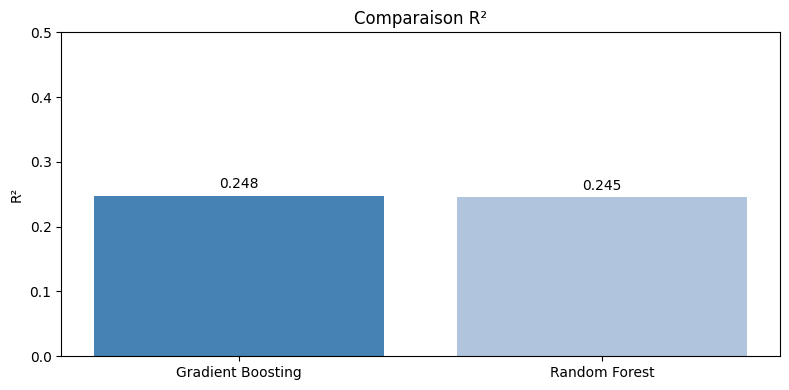

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
couleurs = ['steelblue' if r == df_resultats['R²'].max() else 'lightsteelblue' for r in df_resultats['R²']]
barres = ax.bar(modeles, df_resultats['R²'], color=couleurs)
ax.set_ylabel('R²')
ax.set_title('Comparaison R²')
ax.set_ylim(0, 0.5)
ax.bar_label(barres, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

### Analyse de la comparaison des R²
Ce graphique met en évidence la part de la **variance expliquée** par chaque modèle. Un R² de 1 indique une explication complète des données, alors qu'un R² de 0 indique l'absence de pouvoir explicatif. Gradient Boosting est le meilleur avec R²=0,248, suivi de près par Random Forest (R²=0,245). Ces scores indiquent que **même le modèle avec le R² le plus élevé, Gradient Boosting, n'explique que 24,8% de la variance du nombre de ventes**. Un R² inferieur à 0,3 est vraiment faible. Ça veut dire que près de 75% du nombre de nos ventes reste inexpliqué par les variables utilisées. Cela suggère que les features actuelles du dataset sont insuffisantes pour capturer les facteurs déterminants des ventes.

Modifier les variables données à notre modèle pourrait aider à mieux expliquer le nombre de ventes des jeux vidéos.

## Valeurs réelles vs prédites

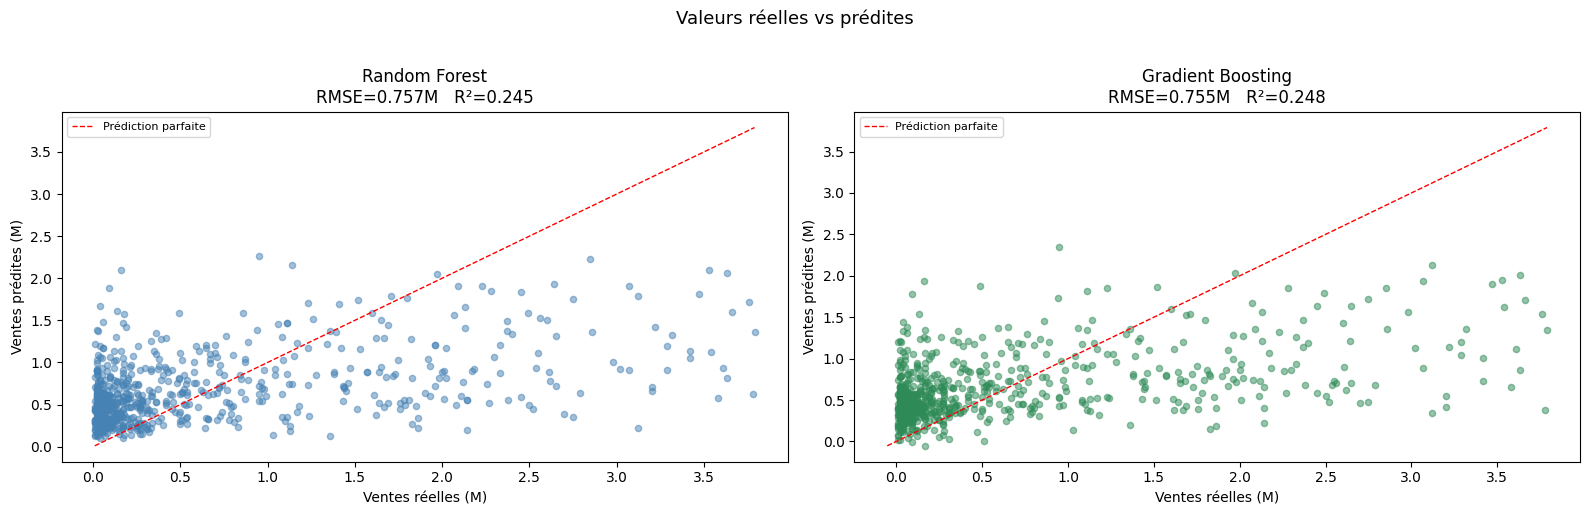

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

donnees = [
    ('Random Forest', y_true, y_pred_rf, rmse_rf, r2_rf, 'steelblue'),
    ('Gradient Boosting', y_true, y_pred_gb, rmse_gb, r2_gb, 'seagreen')
]

for ax, (nom, y_true, y_pred, rmse, r2, couleur) in zip(axes, donnees):
    ax.scatter(y_true, y_pred, alpha=0.5, color=couleur, s=20)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1, label='Prédiction parfaite')
    ax.set_title(f'{nom}\nRMSE={rmse:.3f}M   R²={r2:.3f}')
    ax.set_xlabel('Ventes réelles (M)')
    ax.set_ylabel('Ventes prédites (M)')
    ax.legend(fontsize=8)

plt.suptitle('Valeurs réelles vs prédites', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Analyse de la comparaison des valeurs réelles vs prédites
Sur ces graphiques, on **compare les vraies ventes (axe horizontal) aux ventes prédites (axe vertical) par chaque modèle**. La **ligne rouge pointillée** représente la **prédiction parfaite** : quand un point est dessus, le modèle a deviné exactement la bonne valeur. Si un point est au dessus, alors le modèle sur estime le nombre de ventes, et en dessous, il la sous estime.

- Gradient Boosting :
Avec un RMSE de 0.755 et un R² de 0.248, Gradient Boosting est le plus performant des deux. Cependant, il sous-estime systématiquement les ventes élevées (>2M), où les points s'éloignent nettement de la diagonale et surestime beaucoup les ventes en dessous de 1M.

- Random Forest :
Avec un RMSE de 0.757 et un R² = 0.245, Random Forest a des résultats très proche. La distribution de ses points (en bleu) est similaire à celle du Gradient Boosting. Il échoue lui aussi à prédire les valeurs au dessus de 2M, mais aussi celles en dessous, les surestimant beaucoup.

**Pour conclure, Gradient Boosting est le meilleur des deux modèles. Il a à la fois le RMSE le plus faible et le R² le plus élevé. Il reste néanmoins mauvais, comme Gradient Boosting.**

# Importance des variables dans nos prédictions
Pour calculer l'importance des variables, il faut que l'on entraîne chaque modèle sur tout le dataset

In [25]:
noms_variables = variables_explicatives  # liste des noms de colonnes

## Random Forest
Pour le modèle random forest, feature_importances_ est intégré pour calculer l'importance des varibales explicatives. Il calcule pour chaque variable combien de fois elle a été utilisée pour faire des coupures dans les arbres, et à quel point ces coupures ont réduit l'erreur ou non

In [26]:
rf_final = RandomForestRegressor(
    **best_params_rf,
    random_state     = 42,
    n_jobs           = -1
)
rf_final.fit(X, y)

importances_rf = pd.Series(rf_final.feature_importances_, index=noms_variables)
importances_rf = importances_rf.sort_values()

## Gradient Boosting
Ici aussi, feature_importances_ est intégré

In [27]:
gb_final = GradientBoostingRegressor(**best_params_gb, random_state=42)
gb_final.fit(X, y)

importances_gb = pd.Series(gb_final.feature_importances_, index=noms_variables)
importances_gb = importances_gb.sort_values()

## SVR
Pour le SVR, il n'y a pas d'attribut pour calculer l'importance des variables explicatives. 
On doit donc faire une permutation importance. On entraîne le modèle normalement, puis pour chaque variable on mélange aléatoirement ses valeurs entre tous les jeux. Ensuite, on regarde si les prédictions sont moins bonnes qu'avant ou non. Si les prédictions se dégradent, c'est que la variable était importante. Sinon elle était inutile. Le score peut être négatif puisque l'on fait score_original - score_apres_melange. Si il est négatif, c'est que le score est meilleur qu'avant et donc la variable introduisait du bruit, et le modèle marche mieux sans.

In [28]:
""" scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

svr_final = SVR(**study_svr.best_params)
svr_final.fit(X_scaled, y_log)

result = permutation_importance(
    svr_final, X_scaled, y_log,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances_svr = pd.Series(result.importances_mean, index=noms_variables)
importances_svr = importances_svr.sort_values() """

' scaler_final = StandardScaler()\nX_scaled = scaler_final.fit_transform(X)\n\nsvr_final = SVR(**study_svr.best_params)\nsvr_final.fit(X_scaled, y_log)\n\nresult = permutation_importance(\n    svr_final, X_scaled, y_log,\n    n_repeats=10,\n    random_state=42,\n    n_jobs=-1\n)\n\nimportances_svr = pd.Series(result.importances_mean, index=noms_variables)\nimportances_svr = importances_svr.sort_values() '

## Graphiques

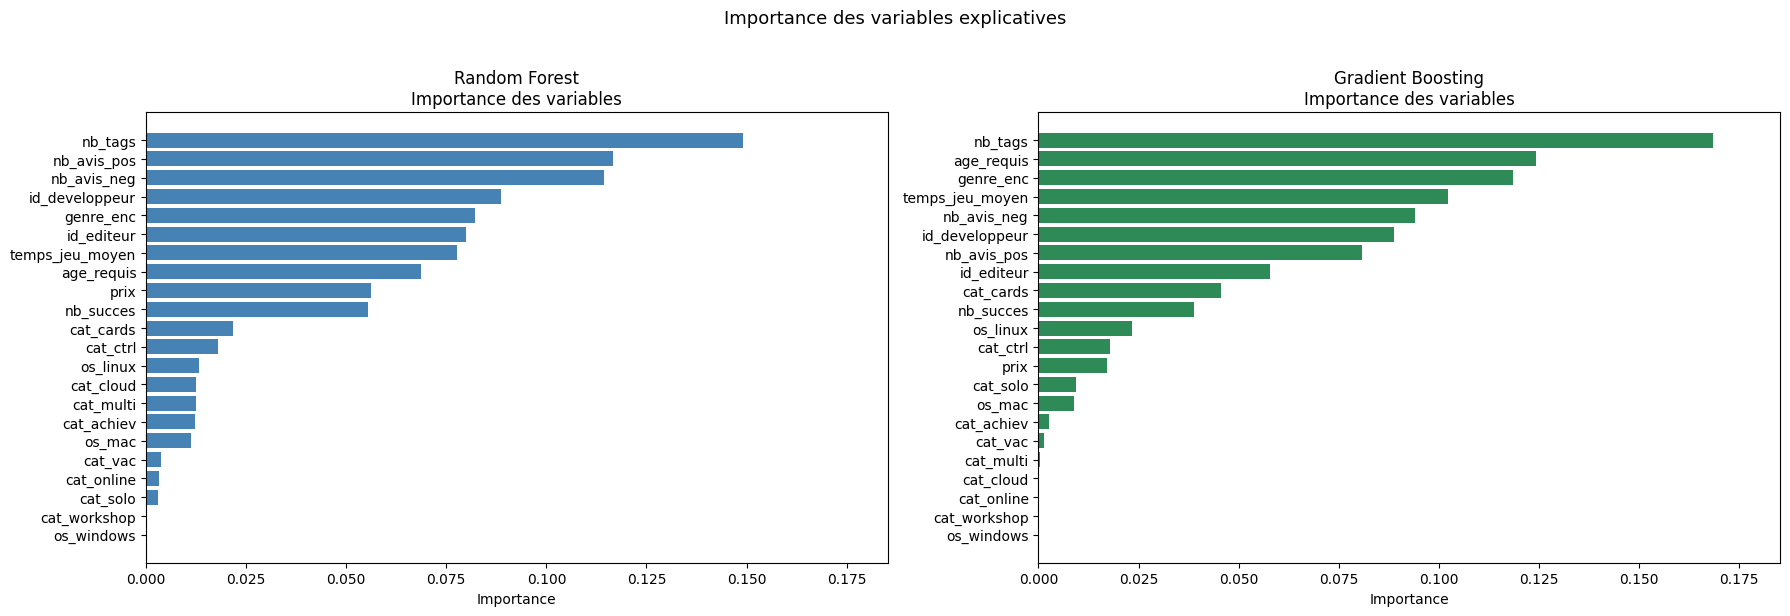

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Valeur max globale
max_importance = max(
    importances_rf.max(), 
    importances_gb.max()
)

# Random Forest
axes[0].barh(importances_rf.index, importances_rf.values, color='steelblue')
axes[0].set_title('Random Forest\nImportance des variables')
axes[0].set_xlabel('Importance')
axes[0].set_xlim(0, max_importance * 1.1)

# Gradient Boosting
axes[1].barh(importances_gb.index, importances_gb.values, color='seagreen')
axes[1].set_title('Gradient Boosting\nImportance des variables')
axes[1].set_xlabel('Importance')
axes[1].set_xlim(0, max_importance * 1.1)

""" # SVR
axes[2].barh(importances_svr.index, importances_svr.values, color='coral')
axes[2].set_title('SVR\nImportance des variables (permutation)')
axes[2].set_xlabel('Importance')
axes[2].set_xlim(0, max_importance * 1.1) """

plt.suptitle('Importance des variables explicatives', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analyse des graphes sur l'importance des variables

Chaque graphe correspond à un modèle différent de machine learning, et **affiche dans l'ordre les variables les plus explicatives du modèle**. C'est-à-dire, **les variables qui permettent au modèle de faire au mieux ses prédictions**.

**Important à savoir :** l'importance des variables explicatives dans le graphe SVR a été calculée différemment, par permutation. Cette méthode peut produire des valeurs négatives si une variable dégrade les performances du modèle.

Pour les deux modèles, on observe que les variables les plus importantes sont concentrées sur quelques variables. Dans Random Forest, les 3 premières variables ("nb_tags","nb_avis_pos","nb_avis_neg") représentent à elles seules une part importante (au dessus de 0.12). Ces variables sont suivies de "id_developpeur","genre","id_editeur", "temps_jeu_moyen", "age_requis", qui sont elles entre 0.06 et 0.08. Gradient Boosting est similaire, avec "nb_tags" en tête au dessus de 0.125, mais avec une distribution légèrement plus étalée sur les variables suivantes entre 0.06 et 0.125 ("age_requis", "genre", "nb_avis_neg", temps_jeu_moyen",  "id_developpeur", "nb_avis_pos", et "id_editeur").
On remarque que ce sont les mêmes variables pour les deux modèles qui ressortent le plus. Le nombre de tags est la variable la plus unanime. Par la suite les 7 autres premières variables sont identiques entre les deux modèles, bien qu'elles ne soient pas dans le même ordre. Nous avons le genre des jeux vidéos, leur nombres d'avis positifs et négatifs, leur développeur et éditeur, l'âge requis pour y jouer et aussi la durée de vie du jeu (temps moyen).
On remarque également que pour les développeurs et éditeurs, ces variables ont été encodées en id, ce sont donc des nombres qui représentent des noms, pas comme les prix par exemple, mais elles ressortent quand même beaucoup. Cela fait sens puisque certains développeurs et éditeurs ont une réputation qui peut beaucoup jouer. C'est pour cela que nous allons entraîner les modèles sur différentes "découpes" de ventes, pour réduire l'effet des gros studios et mieux étudier les autres variables.

**Beaucoup de variables sont très peu utiles** pour les deux modèles car elles sont tout le temps proches de 0 :
- os windows à 0 (logique puisque presque tous les jeux sont sur windows)
- Les autres OS
- Les catégories en général

Les catégories ou systèmes d'exploitation qu'utilisent les jeux ne permettent donc pas d'expliquer leurs ventes.
Le prix et le nombre de succès que possèdent le jeu peuvent jouer modérèment (souvent vers 0.04-0.06).

# Modèles de prédiction pour les jeux à succès modéré
Puisque nos modèles ne fonctionnent pas très bien, mais qu'on remarque 2 catégories dans les prédictions (les jeux qui font peu de ventes sont surestimés alors que les jeux faisant des ventes moyennes sont sous estimés) on a décidé d'essayer de créer 2 types de modèles prédictifs : un modèle pour les jeux faisant des ventes moyennes (pour les développeurs un peu connus en général) et les jeux faisant de petites ventes (souvent des indépendants). Nous allons tout d'abord entraîner nos modèles sur les jeux ayant un succès modéré.

# Nettoyage et préparation des données

## Connexion à la DB

In [30]:
connexion = mysql.connector.connect(
    host     = 'localhost',
    user     = 'root',
    password = '',
    database = 'gamesale'
)

## Création des dataframe

In [31]:
# Table principale
df = pd.read_sql("""
    SELECT
        id_jeu,
        nom_jeu,
        age_requis,
        nb_succes,
        nb_avis_pos,
        nb_avis_neg,
        temps_jeu_moyen,
        prix,
        ventes_Global
    FROM jeux
""", connexion)

# Conversion ventes (virgule/point)
df['ventes_Global'] = df['ventes_Global'].str.replace(',', '.').astype(float)

# Genre (un seul par jeu, on prend le premier)
df_genre = pd.read_sql("""
    SELECT id_jeu, genre
    FROM genre
    GROUP BY id_jeu
""", connexion)

# Éditeur (un seul par jeu)
df_edit = pd.read_sql("""
    SELECT id_jeu, id_editeur
    FROM editeur
    GROUP BY id_jeu
""", connexion)

# Développeur (un seul par jeu)
df_dev = pd.read_sql("""
    SELECT id_jeu, id_developpeur
    FROM developpeur
    GROUP BY id_jeu
""", connexion)

# OS (colonnes binaires 0/1)
df_os = pd.read_sql("""
    SELECT
        id_jeu,
        MAX(CASE WHEN id_os = 1 THEN 1 ELSE 0 END) AS os_windows,
        MAX(CASE WHEN id_os = 2 THEN 1 ELSE 0 END) AS os_mac,
        MAX(CASE WHEN id_os = 3 THEN 1 ELSE 0 END) AS os_linux
    FROM a_os
    GROUP BY id_jeu
""", connexion)

# Catégories (colonnes binaires 0/1)
df_cat = pd.read_sql("""
    SELECT
        id_jeu,
        MAX(CASE WHEN id_cat = '1'  THEN 1 ELSE 0 END) AS cat_multi,
        MAX(CASE WHEN id_cat = '2'  THEN 1 ELSE 0 END) AS cat_online,
        MAX(CASE WHEN id_cat = '4'  THEN 1 ELSE 0 END) AS cat_vac,
        MAX(CASE WHEN id_cat = '5'  THEN 1 ELSE 0 END) AS cat_solo,
        MAX(CASE WHEN id_cat = '6'  THEN 1 ELSE 0 END) AS cat_cloud,
        MAX(CASE WHEN id_cat = '7'  THEN 1 ELSE 0 END) AS cat_achiev,
        MAX(CASE WHEN id_cat = '8'  THEN 1 ELSE 0 END) AS cat_cards,
        MAX(CASE WHEN id_cat = '10' THEN 1 ELSE 0 END) AS cat_ctrl,
        MAX(CASE WHEN id_cat = '22' THEN 1 ELSE 0 END) AS cat_workshop
    FROM a_categorie
    GROUP BY id_jeu
""", connexion)

# Nombre de tags par jeu
curseur = connexion.cursor()
curseur.execute("SELECT * FROM a_tag LIMIT 1")
curseur.fetchall()
toutes_cols   = [description[0] for description in curseur.description]
colonnes_tags = toutes_cols[1:]
somme_tags    = ' + '.join([f'`{col}`' for col in colonnes_tags])

df_tags = pd.read_sql(f"""
    SELECT id_jeu, ({somme_tags}) AS nb_tags
    FROM a_tag
""", connexion)

connexion.close()

## Fusion des dataframe

In [32]:
df = df.merge(df_genre, on='id_jeu', how='left')
df = df.merge(df_edit,  on='id_jeu', how='left')
df = df.merge(df_dev,   on='id_jeu', how='left')
df = df.merge(df_os,    on='id_jeu', how='left')
df = df.merge(df_cat,   on='id_jeu', how='left')
df = df.merge(df_tags,  on='id_jeu', how='left')

print(f"Après fusion : {len(df)} jeux, {len(df.columns)} colonnes")

Après fusion : 780 jeux, 25 colonnes


## Nettoyage des données

In [33]:
# Supprimer les lignes avec des NaN dans les colonnes essentielles
df = df.dropna(subset=['ventes_Global', 'age_requis', 'prix'])

# Remplir les NaN restants
df['genre']          = df['genre'].fillna('Unknown')
df['id_editeur']     = df['id_editeur'].fillna(-1).astype(int)
df['id_developpeur'] = df['id_developpeur'].fillna(-1).astype(int)
df['nb_tags']        = df['nb_tags'].fillna(0)
df = df.fillna(0)

print(f"Après nettoyage NaN : {len(df)} jeux")

Après nettoyage NaN : 780 jeux


## On garde les jeux à succès modéré
Ce sont des jeux qui ont fait entre 0.27M et 3.79M de ventes.

In [34]:
seuil_90= df['ventes_Global'].quantile(0.9)
seuil_50 = df['ventes_Global'].quantile(0.5)
df = df[(df['ventes_Global'] <= seuil_90) & (df['ventes_Global'] >= seuil_50)]

print(f"Après avoir gardé les jeux entre le 7ème et le 9ème décile : {len(df)} jeux")

Après avoir gardé les jeux entre le 7ème et le 9ème décile : 321 jeux


## Encodage des variables catégorielles non encodées (genre)

In [35]:
le_genre = LabelEncoder() #chaque catégorie est remplacée par un nombre entier
df['genre_enc'] = le_genre.fit_transform(df['genre'])

## Variables explicatives

In [36]:
variables_explicatives = [
    'age_requis',
    'nb_succes',
    'nb_avis_pos',
    'nb_avis_neg',
    'temps_jeu_moyen',
    'prix',
    'genre_enc',
    'id_editeur',
    'id_developpeur',
    'os_windows',
    'os_mac',
    'os_linux',
    'cat_multi',
    'cat_online',
    'cat_vac',
    'cat_solo',
    'cat_cloud',
    'cat_achiev',
    'cat_cards',
    'cat_ctrl',
    'cat_workshop',
    'nb_tags',
]

X   = df[variables_explicatives]
y   = df['ventes_Global'].values     # ventes réelles (en millions)
y_log = np.log1p(y)                  # ventes log pour SVR

print(f"\nDataset final : {X.shape[0]} jeux, {X.shape[1]} features")
print(f"Ventes :\nmin: {y.min():.2f}M - max: {y.max():.2f}M - moyenne: {y.mean():.2f}M")
print(f"\nVariables explicatives utilisées :\n")
for f in variables_explicatives:
    print(f"  - {f}")


Dataset final : 321 jeux, 22 features
Ventes :
min: 0.27M - max: 3.79M - moyenne: 1.29M

Variables explicatives utilisées :

  - age_requis
  - nb_succes
  - nb_avis_pos
  - nb_avis_neg
  - temps_jeu_moyen
  - prix
  - genre_enc
  - id_editeur
  - id_developpeur
  - os_windows
  - os_mac
  - os_linux
  - cat_multi
  - cat_online
  - cat_vac
  - cat_solo
  - cat_cloud
  - cat_achiev
  - cat_cards
  - cat_ctrl
  - cat_workshop
  - nb_tags


# Tuning et entraînement des modèles

## Random Forest

### Tuning
Recherche des meilleurs hyperparamètres

In [37]:
study_rf = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_rf.optimize(lambda trial: objective(trial, "random_forest"), n_trials=100, show_progress_bar=True,n_jobs=-1)

Best trial: 88. Best value: 22.9886: 100%|██████████| 100/100 [00:05<00:00, 19.09it/s]


In [38]:
best_params_rf = {
    'n_estimators': 100,
    'max_depth': 18,
    'min_samples_split': 4,
    'min_samples_leaf': 2,
    'max_features': 'sqrt'
}

model = RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1)
print(f"Meilleurs hyperparamètres : {best_params_rf}")

Meilleurs hyperparamètres : {'n_estimators': 100, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt'}


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [39]:
# LOOCV = Leave One Out Cross Validation
# Principe : on a par exemple 100 jeux
#   - Tour 1  : on entraîne sur les jeux 2 à 100, on prédit le jeu 1
#   - Tour 2  : on entraîne sur les jeux 1 et 3 à 100, on prédit le jeu 2
#   - ...
#   - Tour 100 : on entraîne sur les jeux 1 à 99, on prédit le jeu 100
# À la fin, chaque jeu a été prédit exactement une fois, sans jamais
# avoir été utilisé pour l'entraînement de sa propre prédiction

loo = LeaveOneOut()

liste_valeurs_reelles=[]
liste_valeurs_predites=[]

#Boucle LOOCV
nombre_total_tours=len(X)
tour_actuel=0

# la fonction ci dessous a été entièrement toruvée sur internet, mais j'ai pris le temps de bien la comprendre.
for train_idx, test_idx in loo.split(X):
    # loo.split(X) génère à chaque tour :
    #   - train_idx : les indices des jeux utilisés pour l'entraînement
    #   - test_idx  : l'indice du jeu qu'on veut prédire (toujours 1 seul)
    tour_actuel=tour_actuel+1
    
     # On découpe X et y en données d'entraînement et de test
    X_train = X.iloc[train_idx]   # toutes les lignes sauf une
    X_test  = X.iloc[test_idx]    # la ligne qu'on veut prédire

    y_train = y[train_idx]   # les vraies ventes pour l'entraînement
    y_test  = y[test_idx]    # la vraie vente du jeu à prédire

        # ── Normalisation ──
    # On met toutes les features à la même échelle (moyenne=0, écart-type=1)

    scaler      = StandardScaler()
    X_train_normalise = scaler.fit_transform(X_train)  # calcule ET applique
    X_test_normalise  = scaler.transform(X_test)       # applique seulement


    #Entrainement
    # On entraîne le modèle (ici Random Forest qui est dans le chunk précédent) sur les données d'entraînement normalisées
    model.fit(X_train_normalise, y_train)

    #Prédiction 
    # On prédit les ventes du jeu de test
    # [0] car predict() retourne une liste, on veut juste le premier élément
    valeur_predite = model.predict(X_test_normalise)[0]
    valeur_reelle  = y_test[0]

    # On stocke les résultats
    liste_valeurs_predites.append(valeur_predite)
    liste_valeurs_reelles.append(valeur_reelle)

### Résultats

In [40]:
y_pred = np.array(liste_valeurs_predites)
y_true = np.array(liste_valeurs_reelles)


# RMSE = Root Mean Squared Error : erreur typique du modèle en millions d'exemplaires
rmse_rf = np.sqrt(mean_squared_error(y_true, y_pred))

# MAE = Mean Absolute Error : erreur absolue moyenne en millions d'exemplaires
mae_rf = mean_absolute_error(y_true, y_pred)

# R² = coefficient de détermination : entre 0 et 1, indique la part de variance expliquée par le modèle
r2_rf = r2_score(y_true, y_pred)

y_pred_rf =  y_pred.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - Random Forest")
print(f"  RMSE : {rmse_rf:.3f}M En moyenne le modèle se trompe de +-{rmse_rf:.2f} millions")
print(f"  MAE  : {mae_rf:.3f}M")
print(f"  R²   : {r2_rf:.3f}  Le modèle explique {r2_rf*100:.1f}% de la variance des ventes")


Résultats LOOCV - Random Forest
  RMSE : 0.830M En moyenne le modèle se trompe de +-0.83 millions
  MAE  : 0.668M
  R²   : 0.207  Le modèle explique 20.7% de la variance des ventes


## Gradient Boosting

### Tuning
Recherche des meilleurs hyperparamètres. On utilise optuna qui cherche automatiquement les meilleurs hyperparamètres. Il oriente intelligemment les essais vers les meilleures combinaisons en minimisant le RMSE.

In [41]:
study_gb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_gb.optimize(lambda trial: objective(trial, "gradient_boosting"), n_trials=100, show_progress_bar=True,n_jobs=-1)

Best trial: 19. Best value: 21.1397: 100%|██████████| 100/100 [00:08<00:00, 11.48it/s]


In [42]:
best_params_gb = {
    'n_estimators': 350,
    'learning_rate': 0.03391082028765766,
    'max_depth': 4,
    'subsample': 0.998726758471419,
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'max_features': 'sqrt'
}

model = GradientBoostingRegressor(**best_params_gb, random_state=42)
print(f"Meilleurs hyperparamètres : {best_params_gb}")

Meilleurs hyperparamètres : {'n_estimators': 350, 'learning_rate': 0.03391082028765766, 'max_depth': 4, 'subsample': 0.998726758471419, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt'}


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [43]:
# LOOCV = Leave One Out Cross Validation
# Principe : on a par exemple 100 jeux
#   - Tour 1  : on entraîne sur les jeux 2 à 100, on prédit le jeu 1
#   - Tour 2  : on entraîne sur les jeux 1 et 3 à 100, on prédit le jeu 2
#   - ...
#   - Tour 100 : on entraîne sur les jeux 1 à 99, on prédit le jeu 100
# À la fin, chaque jeu a été prédit exactement une fois, sans jamais
# avoir été utilisé pour l'entraînement de sa propre prédiction

loo = LeaveOneOut()

liste_valeurs_reelles=[]
liste_valeurs_predites=[]

#Boucle LOOCV
nombre_total_tours=len(X)
tour_actuel=0

# la fonction ci dessous a été entièrement toruvée sur internet, mais j'ai pris le temps de bien la comprendre.
for train_idx, test_idx in loo.split(X):
    # loo.split(X) génère à chaque tour :
    #   - train_idx : les indices des jeux utilisés pour l'entraînement
    #   - test_idx  : l'indice du jeu qu'on veut prédire (toujours 1 seul)
    tour_actuel=tour_actuel+1
    
     # On découpe X et y en données d'entraînement et de test
    X_train = X.iloc[train_idx]   # toutes les lignes sauf une
    X_test  = X.iloc[test_idx]    # la ligne qu'on veut prédire

    y_train = y[train_idx]   # les vraies ventes pour l'entraînement
    y_test  = y[test_idx]    # la vraie vente du jeu à prédire

        # ── Normalisation ──
    # On met toutes les features à la même échelle (moyenne=0, écart-type=1)

    scaler      = StandardScaler()
    X_train_normalise = scaler.fit_transform(X_train)  # calcule ET applique
    X_test_normalise  = scaler.transform(X_test)       # applique seulement


    #Entrainement
    # On entraîne le modèle (ici Gradient Boosting qui est dans le chunk précédent) sur les données d'entraînement normalisées
    model.fit(X_train_normalise, y_train)

    #Prédiction 
    # On prédit les ventes du jeu de test
    # [0] car predict() retourne une liste, on veut juste le premier élément
    valeur_predite = model.predict(X_test_normalise)[0]
    valeur_reelle  = y_test[0]

    # On stocke les résultats
    liste_valeurs_predites.append(valeur_predite)
    liste_valeurs_reelles.append(valeur_reelle)

### Résultats

In [44]:
y_pred = np.array(liste_valeurs_predites)
y_true = np.array(liste_valeurs_reelles)


# RMSE = Root Mean Squared Error : erreur typique du modèle en millions d'exemplaires
rmse_gb = np.sqrt(mean_squared_error(y_true, y_pred))

# MAE = Mean Absolute Error : erreur absolue moyenne en millions d'exemplaires
mae_gb = mean_absolute_error(y_true, y_pred)

# R² = coefficient de détermination : entre 0 et 1, indique la part de variance expliquée par le modèle
r2_gb = r2_score(y_true, y_pred)

y_pred_gb =  y_pred.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - Gradient Boosting")
print(f"  RMSE : {rmse_gb:.3f}M En moyenne le modèle se trompe de +-{rmse_gb:.2f} millions")
print(f"  MAE  : {mae_gb:.3f}M")
print(f"  R²   : {r2_gb:.3f}  Le modèle explique {r2_gb*100:.1f}% de la variance des ventes")


Résultats LOOCV - Gradient Boosting
  RMSE : 0.839M En moyenne le modèle se trompe de +-0.84 millions
  MAE  : 0.661M
  R²   : 0.191  Le modèle explique 19.1% de la variance des ventes


# Comparaison des modèles

## Tableau récapitulatif

In [45]:
resultats = {
    'Modèle':             ['Random Forest', 'Gradient Boosting'],
    'RMSE (M)':           [rmse_rf, rmse_gb],
    'MAE (M)':            [mae_rf,  mae_gb],
    'R²':                 [r2_rf,   r2_gb]
}

df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values('RMSE (M)')
print(df_resultats.to_string(index=False))

           Modèle  RMSE (M)  MAE (M)       R²
    Random Forest  0.830408 0.667583 0.206717
Gradient Boosting  0.838663 0.661482 0.190866


## Comparaison RMSE et MAE

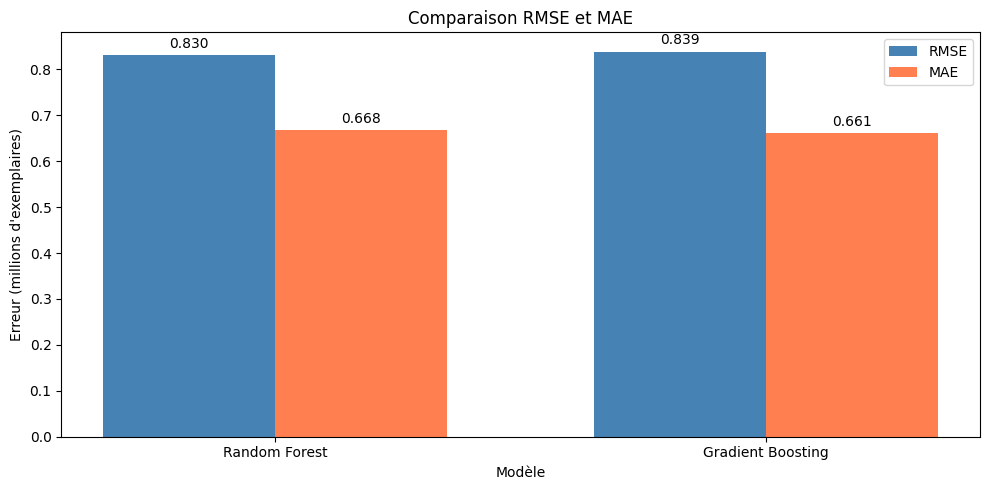

In [46]:
modeles = df_resultats['Modèle'].values
x = np.arange(len(modeles))
largeur = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
barres_rmse = ax.bar(x - largeur/2, df_resultats['RMSE (M)'], largeur, label='RMSE', color='steelblue')
barres_mae  = ax.bar(x + largeur/2, df_resultats['MAE (M)'],  largeur, label='MAE',  color='coral')

ax.set_xlabel('Modèle')
ax.set_ylabel('Erreur (millions d\'exemplaires)')
ax.set_title('Comparaison RMSE et MAE')
ax.set_xticks(x)
ax.set_xticklabels(modeles)
ax.legend()
ax.bar_label(barres_rmse, fmt='%.3f', padding=3)
ax.bar_label(barres_mae,  fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

### Analyse de la comparaison du RMSE et MAE
Ici, **Random Forest** obtient les **meilleurs résultats en RMSE =0.830** comparé à 839 pour Gradient Boosting, alors que ce dernier a lui les **meilleurs résultats en MAE = 0.661** comparé à 668 pour Random Forest. Ainsi, Random Forest gère mieux les valeurs extrêmes (RMSE plus bas) tandis que Gradient Boosting est plus précis en moyenne sur l'ensemble des prédictions (MAE plus bas). Si les grosses erreurs de prédiction sont coûteuses, on privilégierait Random Forest, alors que si on veut minimiser l'erreur sur n'importe quel jeu, Gradient Boosting est légèrement meilleur.
Puisque les valeurs sont proches, les deux modèles seront légèrement similaires. Nous travaillons sur les jeux vidéos donc Random Forest serait sûrement à priviléger, puisque on préfère éviter de sur ou sous prédire les ventes d'un jeu vidéo.

Cependant, nous avons pu remarquer que les valeurs des RMSE et MAE ont augmenté en comparaison avec le dataset complet :
- Gradient Boosting est passé de RMSE=0.755 à RMSE=0.839 et MAE=0.546 à MAE=0.661
- Random Forest est passé de RMSE=0.757 à RMSE=0.830 et MAE=0.547 à MAE=0.668

De plus, les RMSE rapportés à la plage de ventes du dataset (0.27M à 3.79) démontrent que les modèles commettent une erreur moyenne représentant environ 22% de l'amplitude totale des ventes.

Les augmentations d'erreurs sont sûrement dues au fait de filtrer nos données (il ne nous en restait plus que 321), ce qui empêche les modèles de faire des généralités.
L'écart entre RMSE et MAE est d'environ 0,34M pour les deux modèles. Rapporté à la plage de ventes du dataset (0,27M à 3.79M), cet écart reste notable et suggère la présence de valeurs aberrantes au sein même de cette catégorie de jeux à succès modéré.

**Pour conclure, nous pouvons donc en déduire qu'il n'est pas  utile d'utiliser cette version de prédiction de vente d'un jeu, mais qu'au contraire il serait préférable de garder la version préservant le dataset complet**.

## Comparaison des R²

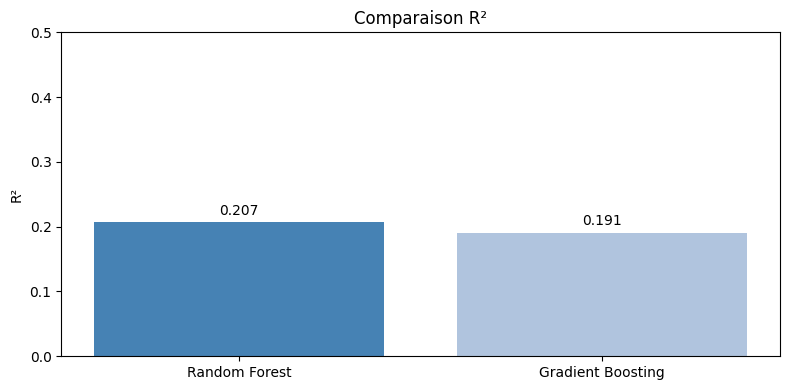

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))
couleurs = ['steelblue' if r == df_resultats['R²'].max() else 'lightsteelblue' for r in df_resultats['R²']]
barres = ax.bar(modeles, df_resultats['R²'], color=couleurs)
ax.set_ylabel('R²')
ax.set_title('Comparaison R²')
ax.set_ylim(0, 0.5)
ax.bar_label(barres, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

### Analyse de la comparaison des R²
Une fois de plus, Random Forest est le meilleur modèle avec R²=0.207. Gradient Boosting a quant à lui un R² de 0.191.
On remarque cependant une diminution du R² pour chaque modèle :
- Gradient Boosting est passé de R²=0.248 à R²=0.191
- Random Forest est passé de R²=0.245 à R²=0.207

Ainsi, **Random Forest obtient le meilleur résultat** et peut expliquer 20.7% de la variance des ventes. Cependant c'est une valeur trop faible pour envisager une utilisation fiable.
Les performances restent limitées malgré le filtrage du dataset. Malgré l'aménagement des données, près de 80% de la variance des ventes est inexpliquée. Cela confirme que les "features" actuelles sont **insuffisantes pour modéliser efficacement** les facteurs de succès commercial des jeux vidéo.

## Valeurs réelles vs prédites

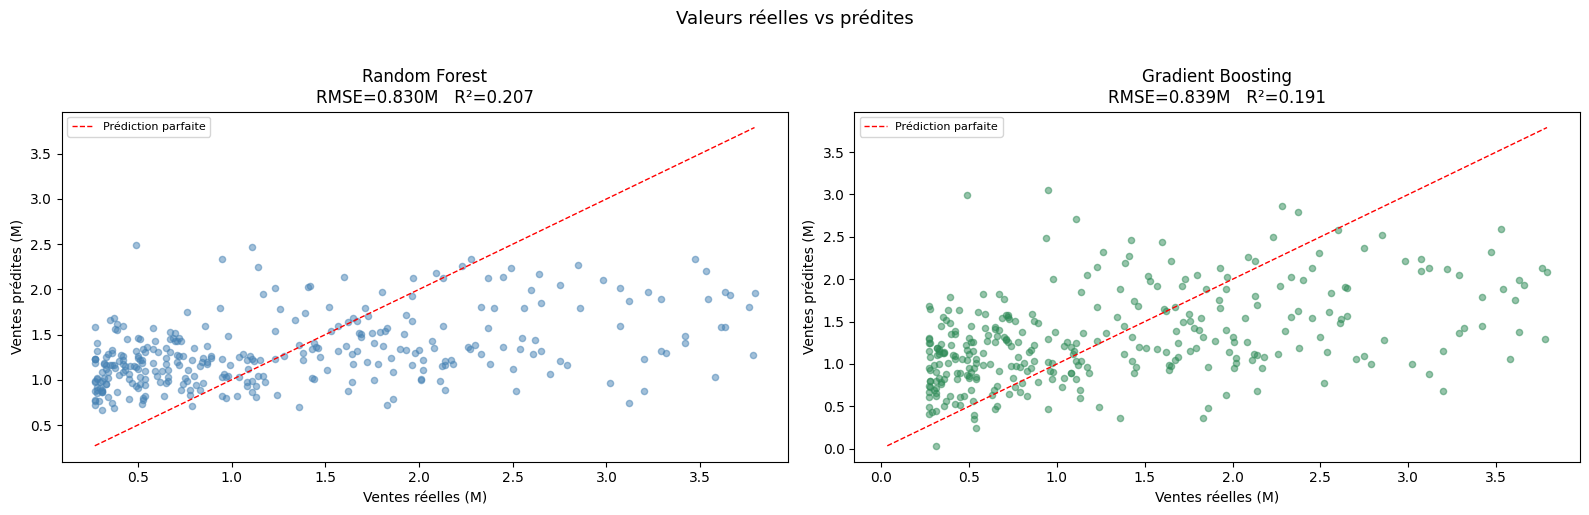

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

donnees = [
    ('Random Forest', y_true, y_pred_rf, rmse_rf, r2_rf, 'steelblue'),
    ('Gradient Boosting', y_true, y_pred_gb, rmse_gb, r2_gb, 'seagreen')
]

for ax, (nom, y_true, y_pred, rmse, r2, couleur) in zip(axes, donnees):
    ax.scatter(y_true, y_pred, alpha=0.5, color=couleur, s=20)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1, label='Prédiction parfaite')
    ax.set_title(f'{nom}\nRMSE={rmse:.3f}M   R²={r2:.3f}')
    ax.set_xlabel('Ventes réelles (M)')
    ax.set_ylabel('Ventes prédites (M)')
    ax.legend(fontsize=8)

plt.suptitle('Valeurs réelles vs prédites', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Analyse de la comparaison des valeurs réelles vs prédites
- Random Forest :
Avec un RMSE de 0.830 et un R² = 0.207, Random Forest est le plus performant des deux. Cependant, les deux graphes sont très similaires. Comme Gradient Boosting, il sous-estime systématiquement les ventes élevées (>2M), où les points s'éloignent nettement de la diagonale et surestime les ventes basses (<1M).

- Gradient Boosting :
Gradient Boosting affiche des résultats très proches (RMSE = 0,839, R² = 0,191). La distribution de ses points est similaire à celle du Random Forest, avec une légère dispersion supplémentaire pour les ventes entre 0 et 1M. Il échoue lui aussi à prédire les valeurs au dessus de 2M.

**Au final, Random Forest est le meilleur des deux modèles. Il est celui qui a à la fois le RMSE le plus faible et le R² le plus élevé. Il reste néanmoins mauvais sur les valeurs extrêmes, comme les autres modèles.**

On aurait pu s'attendre à ce que réduire la plage de ventes facilite la prédiction, les ventes étant plus homogènes. Pourtant, les performances restent similaires voire moins bonnes qu'avec le dataset complet. Cela est sûrement du au fait que les modèles avaient moins de données disponibles pour l'apprentissage.

# Importance des variables dans nos prédictions
Pour calculer l'importance des variables, il faut que l'on entraîne chaque modèle sur tout le dataset

In [49]:
noms_variables = variables_explicatives  # liste des noms de colonnes

## Random Forest
Pour le modèle random forest, feature_importances_ est intégré pour calculer l'importance des varibales explicatives. Il calcule pour chaque variable combien de fois elle a été utilisée pour faire des coupures dans les arbres, et à quel point ces coupures ont réduit l'erreur ou non

In [50]:
rf_final = RandomForestRegressor(
    **best_params_rf,
    random_state     = 42,
    n_jobs           = -1
)
rf_final.fit(X, y)

importances_rf = pd.Series(rf_final.feature_importances_, index=noms_variables)
importances_rf = importances_rf.sort_values()

## Gradient Boosting
Ici aussi, feature_importances_ est intégré

In [51]:
gb_final = GradientBoostingRegressor(**best_params_gb, random_state=42)
gb_final.fit(X, y)

importances_gb = pd.Series(gb_final.feature_importances_, index=noms_variables)
importances_gb = importances_gb.sort_values()

## Graphiques

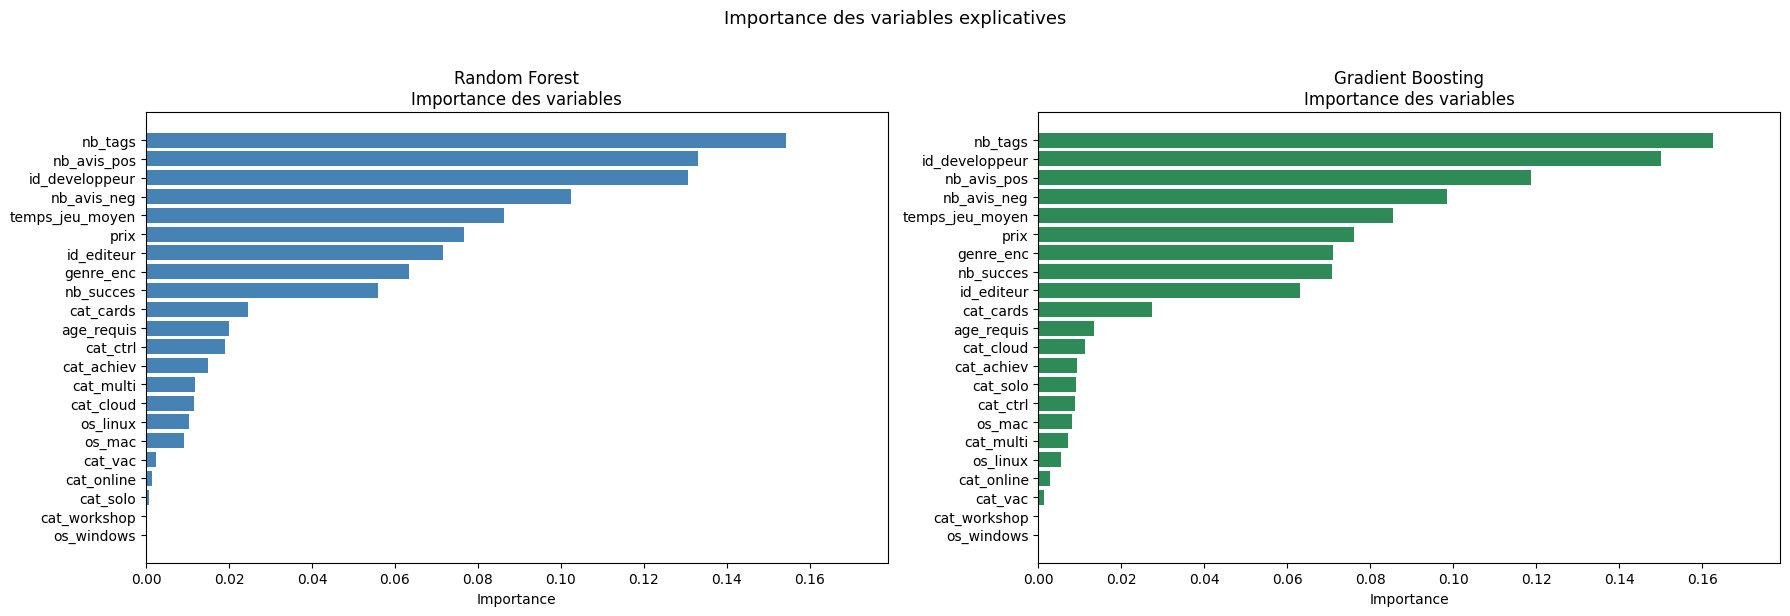

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Valeur max globale
max_importance = max(
    importances_rf.max(), 
    importances_gb.max()
)

# Random Forest
axes[0].barh(importances_rf.index, importances_rf.values, color='steelblue')
axes[0].set_title('Random Forest\nImportance des variables')
axes[0].set_xlabel('Importance')
axes[0].set_xlim(0, max_importance * 1.1)

# Gradient Boosting
axes[1].barh(importances_gb.index, importances_gb.values, color='seagreen')
axes[1].set_title('Gradient Boosting\nImportance des variables')
axes[1].set_xlabel('Importance')
axes[1].set_xlim(0, max_importance * 1.1)

plt.suptitle('Importance des variables explicatives', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analyse des graphes sur l'importance des variables

Ici encore pour les deux modèles, on observe que les variables les plus importantes sont concentrées sur quelques variables. Dans Random Forest, les 3 premières variables ont légèrement changé ("nb_tags","nb_avis_pos", "id_developpeur"). Elles représentent à elles seules une part importante (au dessus de 0.1). Ces variables sont suivies de "nb_avis_neg","temps_jeu_moyen","id_editeur","prix", "genre" et "nb_succes", qui sont elles entre 0.06 et 0.1. Gradient Boosting est similaire, avec "nb_tags" et "id_developpeur" en tête au dessus de 0.12, mais avec une distribution légèrement plus étalée sur les variables suivantes entre 0.06 et 0.1 ("nb_avis_pos", "temps_jeu_moyen", "nb_avis_neg", "prix" et "id_editeur","genre", et "nb_succes").
On remarque que ce sont les mêmes variables pour les deux modèles qui ressortent le plus, mais qu'elles ont changé. En effet, l'age requis est devenu très peu important, et les développeurs comptent pour une grosse part de l'explication (environ 0.13 pour random forest et environ 0.15 pour gradient boosting). Cela suggère que les développeurs restent important même pour les jeux "moyens". Le prix quant à lui a également gagné en importance alors qu'il n'expliquait que peu la vente des jeux vidéos avec tout le dataset.

Pour les jeux dits "moyens", il semblerait que les variables explicatives auxquelles on s'attendrait en pensant aux jeux vidéos sont remontées en importance : développeur, éditeur, avis, durée de jeu, prix, genre. Les catégories et les systèmes d'exploitations n'ont toujours presque pas d'importance dans la vente des jeux vidéos.
Cependant, ici comme sur tout le dataset, le nombre de tags que possède un jeu vidéo a la plus grande importance. On pourrait se demander si les jeux qui font le plus de ventes sont plus détaillés sur steam, ou si le nombre de tags rentrés met le jeu en avant par exemple. 

# Modèles de prédiction pour les jeux avec peu de ventes
Comme dit précedemment, nous avions vu qu'il semblait il y avait 2 catégories de jeux vidéos. Nous allons donc maintenant tester des prédictions sur les jeux à faible ventes (en dessous de 1.04M).

# Nettoyage et préparation des données

## Connexion à la DB

In [53]:
connexion = mysql.connector.connect(
    host     = 'localhost',
    user     = 'root',
    password = '',
    database = 'gamesale'
)

## Création des dataframe

In [54]:
# Table principale
df = pd.read_sql("""
    SELECT
        id_jeu,
        nom_jeu,
        age_requis,
        nb_succes,
        nb_avis_pos,
        nb_avis_neg,
        temps_jeu_moyen,
        prix,
        ventes_Global
    FROM jeux
""", connexion)

# Conversion ventes (virgule/point)
df['ventes_Global'] = df['ventes_Global'].str.replace(',', '.').astype(float)

# Genre (un seul par jeu, on prend le premier)
df_genre = pd.read_sql("""
    SELECT id_jeu, genre
    FROM genre
    GROUP BY id_jeu
""", connexion)

# Éditeur (un seul par jeu)
df_edit = pd.read_sql("""
    SELECT id_jeu, id_editeur
    FROM editeur
    GROUP BY id_jeu
""", connexion)

# Développeur (un seul par jeu)
df_dev = pd.read_sql("""
    SELECT id_jeu, id_developpeur
    FROM developpeur
    GROUP BY id_jeu
""", connexion)

# OS (colonnes binaires 0/1)
df_os = pd.read_sql("""
    SELECT
        id_jeu,
        MAX(CASE WHEN id_os = 1 THEN 1 ELSE 0 END) AS os_windows,
        MAX(CASE WHEN id_os = 2 THEN 1 ELSE 0 END) AS os_mac,
        MAX(CASE WHEN id_os = 3 THEN 1 ELSE 0 END) AS os_linux
    FROM a_os
    GROUP BY id_jeu
""", connexion)

# Catégories (colonnes binaires 0/1)
df_cat = pd.read_sql("""
    SELECT
        id_jeu,
        MAX(CASE WHEN id_cat = '1'  THEN 1 ELSE 0 END) AS cat_multi,
        MAX(CASE WHEN id_cat = '2'  THEN 1 ELSE 0 END) AS cat_online,
        MAX(CASE WHEN id_cat = '4'  THEN 1 ELSE 0 END) AS cat_vac,
        MAX(CASE WHEN id_cat = '5'  THEN 1 ELSE 0 END) AS cat_solo,
        MAX(CASE WHEN id_cat = '6'  THEN 1 ELSE 0 END) AS cat_cloud,
        MAX(CASE WHEN id_cat = '7'  THEN 1 ELSE 0 END) AS cat_achiev,
        MAX(CASE WHEN id_cat = '8'  THEN 1 ELSE 0 END) AS cat_cards,
        MAX(CASE WHEN id_cat = '10' THEN 1 ELSE 0 END) AS cat_ctrl,
        MAX(CASE WHEN id_cat = '22' THEN 1 ELSE 0 END) AS cat_workshop
    FROM a_categorie
    GROUP BY id_jeu
""", connexion)

# Nombre de tags par jeu
curseur = connexion.cursor()
curseur.execute("SELECT * FROM a_tag LIMIT 1")
curseur.fetchall()
toutes_cols   = [description[0] for description in curseur.description]
colonnes_tags = toutes_cols[1:]
somme_tags    = ' + '.join([f'`{col}`' for col in colonnes_tags])

df_tags = pd.read_sql(f"""
    SELECT id_jeu, ({somme_tags}) AS nb_tags
    FROM a_tag
""", connexion)

connexion.close()

## Fusion des dataframe

In [55]:
df = df.merge(df_genre, on='id_jeu', how='left')
df = df.merge(df_edit,  on='id_jeu', how='left')
df = df.merge(df_dev,   on='id_jeu', how='left')
df = df.merge(df_os,    on='id_jeu', how='left')
df = df.merge(df_cat,   on='id_jeu', how='left')
df = df.merge(df_tags,  on='id_jeu', how='left')

print(f"Après fusion : {len(df)} jeux, {len(df.columns)} colonnes")

Après fusion : 780 jeux, 25 colonnes


## Nettoyage des données

In [56]:
# Supprimer les lignes avec des NaN dans les colonnes essentielles
df = df.dropna(subset=['ventes_Global', 'age_requis', 'prix'])

# Remplir les NaN restants
df['genre']          = df['genre'].fillna('Unknown')
df['id_editeur']     = df['id_editeur'].fillna(-1).astype(int)
df['id_developpeur'] = df['id_developpeur'].fillna(-1).astype(int)
df['nb_tags']        = df['nb_tags'].fillna(0)
df = df.fillna(0)

print(f"Après nettoyage NaN : {len(df)} jeux")

Après nettoyage NaN : 780 jeux


## Filtrage des données (retirer quantile>0.7)
On garde les jeux à faible ventes, donc des jeux à moins de 1.04M de ventes.

In [57]:
seuil_70 = df['ventes_Global'].quantile(0.70)
df = df[df['ventes_Global'] <= seuil_70]

print(f"Après suppression des jeux au dessus du 7ème décile : {len(df)} jeux")

Après suppression des jeux au dessus du 7ème décile : 546 jeux


## Encodage des variables catégorielles non encodées (genre)

In [58]:
le_genre = LabelEncoder() #chaque catégorie est remplacée par un nombre entier
df['genre_enc'] = le_genre.fit_transform(df['genre'])

## Variables explicatives

In [59]:
variables_explicatives = [
    'age_requis',
    'nb_succes',
    'nb_avis_pos',
    'nb_avis_neg',
    'temps_jeu_moyen',
    'prix',
    'genre_enc',
    'id_editeur',
    'id_developpeur',
    'os_windows',
    'os_mac',
    'os_linux',
    'cat_multi',
    'cat_online',
    'cat_vac',
    'cat_solo',
    'cat_cloud',
    'cat_achiev',
    'cat_cards',
    'cat_ctrl',
    'cat_workshop',
    'nb_tags',
]

X   = df[variables_explicatives]
y   = df['ventes_Global'].values     # ventes réelles (en millions)
y_log = np.log1p(y)                  # ventes log pour SVR

print(f"\nDataset final : {X.shape[0]} jeux, {X.shape[1]} features")
print(f"Ventes :\nmin: {y.min():.2f}M - max: {y.max():.2f}M - moyenne: {y.mean():.2f}M")
print(f"\nVariables explicatives utilisées :\n")
for f in variables_explicatives:
    print(f"  - {f}")


Dataset final : 546 jeux, 22 features
Ventes :
min: 0.01M - max: 1.04M - moyenne: 0.23M

Variables explicatives utilisées :

  - age_requis
  - nb_succes
  - nb_avis_pos
  - nb_avis_neg
  - temps_jeu_moyen
  - prix
  - genre_enc
  - id_editeur
  - id_developpeur
  - os_windows
  - os_mac
  - os_linux
  - cat_multi
  - cat_online
  - cat_vac
  - cat_solo
  - cat_cloud
  - cat_achiev
  - cat_cards
  - cat_ctrl
  - cat_workshop
  - nb_tags


# Tuning et entraînement des modèles

## Random Forest

### Tuning
Recherche des meilleurs hyperparamètres

In [60]:
study_rf = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_rf.optimize(lambda trial: objective(trial, "random_forest"), n_trials=100, show_progress_bar=True,n_jobs=-1)

Best trial: 35. Best value: 81.9057: 100%|██████████| 100/100 [00:09<00:00, 10.17it/s]


In [61]:
best_params_rf = {
    'n_estimators': 50,
    'max_depth': 4,
    'min_samples_split': 12,
    'min_samples_leaf': 6,
    'max_features': None
}

model = RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1)
print(f"Meilleurs hyperparamètres : {best_params_rf}")

Meilleurs hyperparamètres : {'n_estimators': 50, 'max_depth': 4, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': None}


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [62]:
# LOOCV = Leave One Out Cross Validation
# Principe : on a par exemple 100 jeux
#   - Tour 1  : on entraîne sur les jeux 2 à 100, on prédit le jeu 1
#   - Tour 2  : on entraîne sur les jeux 1 et 3 à 100, on prédit le jeu 2
#   - ...
#   - Tour 100 : on entraîne sur les jeux 1 à 99, on prédit le jeu 100
# À la fin, chaque jeu a été prédit exactement une fois, sans jamais
# avoir été utilisé pour l'entraînement de sa propre prédiction

loo = LeaveOneOut()

liste_valeurs_reelles=[]
liste_valeurs_predites=[]

#Boucle LOOCV
nombre_total_tours=len(X)
tour_actuel=0

# la fonction ci dessous a été entièrement toruvée sur internet, mais j'ai pris le temps de bien la comprendre.
for train_idx, test_idx in loo.split(X):
    # loo.split(X) génère à chaque tour :
    #   - train_idx : les indices des jeux utilisés pour l'entraînement
    #   - test_idx  : l'indice du jeu qu'on veut prédire (toujours 1 seul)
    tour_actuel=tour_actuel+1
    
     # On découpe X et y en données d'entraînement et de test
    X_train = X.iloc[train_idx]   # toutes les lignes sauf une
    X_test  = X.iloc[test_idx]    # la ligne qu'on veut prédire

    y_train = y[train_idx]   # les vraies ventes pour l'entraînement
    y_test  = y[test_idx]    # la vraie vente du jeu à prédire

        # ── Normalisation ──
    # On met toutes les features à la même échelle (moyenne=0, écart-type=1)

    scaler      = StandardScaler()
    X_train_normalise = scaler.fit_transform(X_train)  # calcule ET applique
    X_test_normalise  = scaler.transform(X_test)       # applique seulement


    #Entrainement
    # On entraîne le modèle (ici Random Forest qui est dans le chunk précédent) sur les données d'entraînement normalisées
    model.fit(X_train_normalise, y_train)

    #Prédiction 
    # On prédit les ventes du jeu de test
    # [0] car predict() retourne une liste, on veut juste le premier élément
    valeur_predite = model.predict(X_test_normalise)[0]
    valeur_reelle  = y_test[0]

    # On stocke les résultats
    liste_valeurs_predites.append(valeur_predite)
    liste_valeurs_reelles.append(valeur_reelle)

### Résultats

In [63]:
y_pred = np.array(liste_valeurs_predites)
y_true = np.array(liste_valeurs_reelles)


# RMSE = Root Mean Squared Error : erreur typique du modèle en millions d'exemplaires
rmse_rf = np.sqrt(mean_squared_error(y_true, y_pred))

# MAE = Mean Absolute Error : erreur absolue moyenne en millions d'exemplaires
mae_rf = mean_absolute_error(y_true, y_pred)

# R² = coefficient de détermination : entre 0 et 1, indique la part de variance expliquée par le modèle
r2_rf = r2_score(y_true, y_pred)

y_pred_rf =  y_pred.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - Random Forest")
print(f"  RMSE : {rmse_rf:.3f}M En moyenne le modèle se trompe de +-{rmse_rf:.2f} millions")
print(f"  MAE  : {mae_rf:.3f}M")
print(f"  R²   : {r2_rf:.3f}  Le modèle explique {r2_rf*100:.1f}% de la variance des ventes")


Résultats LOOCV - Random Forest
  RMSE : 0.231M En moyenne le modèle se trompe de +-0.23 millions
  MAE  : 0.175M
  R²   : 0.153  Le modèle explique 15.3% de la variance des ventes


## Gradient Boosting

### Tuning
Recherche des meilleurs hyperparamètres. On utilise optuna qui cherche automatiquement les meilleurs hyperparamètres. Il oriente intelligemment les essais vers les meilleures combinaisons en minimisant le RMSE.

In [64]:
study_gb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_gb.optimize(lambda trial: objective(trial, "gradient_boosting"), n_trials=100, show_progress_bar=True,n_jobs=-1)

Best trial: 52. Best value: 79.112: 100%|██████████| 100/100 [00:06<00:00, 15.39it/s]


In [65]:
best_params_gb = {
    'n_estimators': 400,
    'learning_rate': 0.014385435978518381,
    'max_depth': 3,
    'subsample': 0.6235482668206153,
    'min_samples_split': 2,
    'min_samples_leaf': 10,
    'max_features': 'log2'
}

model = GradientBoostingRegressor(**best_params_gb, random_state=42)
print(f"Meilleurs hyperparamètres : {best_params_gb}")

Meilleurs hyperparamètres : {'n_estimators': 400, 'learning_rate': 0.014385435978518381, 'max_depth': 3, 'subsample': 0.6235482668206153, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'log2'}


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [66]:
# LOOCV = Leave One Out Cross Validation
# Principe : on a par exemple 100 jeux
#   - Tour 1  : on entraîne sur les jeux 2 à 100, on prédit le jeu 1
#   - Tour 2  : on entraîne sur les jeux 1 et 3 à 100, on prédit le jeu 2
#   - ...
#   - Tour 100 : on entraîne sur les jeux 1 à 99, on prédit le jeu 100
# À la fin, chaque jeu a été prédit exactement une fois, sans jamais
# avoir été utilisé pour l'entraînement de sa propre prédiction

loo = LeaveOneOut()

liste_valeurs_reelles=[]
liste_valeurs_predites=[]

#Boucle LOOCV
nombre_total_tours=len(X)
tour_actuel=0

# la fonction ci dessous a été entièrement toruvée sur internet, mais j'ai pris le temps de bien la comprendre.
for train_idx, test_idx in loo.split(X):
    # loo.split(X) génère à chaque tour :
    #   - train_idx : les indices des jeux utilisés pour l'entraînement
    #   - test_idx  : l'indice du jeu qu'on veut prédire (toujours 1 seul)
    tour_actuel=tour_actuel+1
    
     # On découpe X et y en données d'entraînement et de test
    X_train = X.iloc[train_idx]   # toutes les lignes sauf une
    X_test  = X.iloc[test_idx]    # la ligne qu'on veut prédire

    y_train = y[train_idx]   # les vraies ventes pour l'entraînement
    y_test  = y[test_idx]    # la vraie vente du jeu à prédire

        # ── Normalisation ──
    # On met toutes les features à la même échelle (moyenne=0, écart-type=1)

    scaler      = StandardScaler()
    X_train_normalise = scaler.fit_transform(X_train)  # calcule ET applique
    X_test_normalise  = scaler.transform(X_test)       # applique seulement


    #Entrainement
    # On entraîne le modèle (ici Gradient Boosting qui est dans le chunk précédent) sur les données d'entraînement normalisées
    model.fit(X_train_normalise, y_train)

    #Prédiction 
    # On prédit les ventes du jeu de test
    # [0] car predict() retourne une liste, on veut juste le premier élément
    valeur_predite = model.predict(X_test_normalise)[0]
    valeur_reelle  = y_test[0]

    # On stocke les résultats
    liste_valeurs_predites.append(valeur_predite)
    liste_valeurs_reelles.append(valeur_reelle)

### Résultats

In [67]:
y_pred = np.array(liste_valeurs_predites)
y_true = np.array(liste_valeurs_reelles)


# RMSE = Root Mean Squared Error : erreur typique du modèle en millions d'exemplaires
rmse_gb = np.sqrt(mean_squared_error(y_true, y_pred))

# MAE = Mean Absolute Error : erreur absolue moyenne en millions d'exemplaires
mae_gb = mean_absolute_error(y_true, y_pred)

# R² = coefficient de détermination : entre 0 et 1, indique la part de variance expliquée par le modèle
r2_gb = r2_score(y_true, y_pred)

y_pred_gb =  y_pred.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - Gradient Boosting")
print(f"  RMSE : {rmse_gb:.3f}M En moyenne le modèle se trompe de +-{rmse_gb:.2f} millions")
print(f"  MAE  : {mae_gb:.3f}M")
print(f"  R²   : {r2_gb:.3f}  Le modèle explique {r2_gb*100:.1f}% de la variance des ventes")


Résultats LOOCV - Gradient Boosting
  RMSE : 0.228M En moyenne le modèle se trompe de +-0.23 millions
  MAE  : 0.171M
  R²   : 0.180  Le modèle explique 18.0% de la variance des ventes


# Comparaison des modèles

## Tableau récapitulatif

In [68]:
resultats = {
    'Modèle':             ['Random Forest', 'Gradient Boosting'],
    'RMSE (M)':           [rmse_rf, rmse_gb],
    'MAE (M)':            [mae_rf,  mae_gb],
    'R²':                 [r2_rf,   r2_gb]
}

df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values('RMSE (M)')
print(df_resultats.to_string(index=False))

           Modèle  RMSE (M)  MAE (M)       R²
Gradient Boosting  0.227578 0.171139 0.180184
    Random Forest  0.231260 0.174577 0.153442


## Comparaison RMSE et MAE

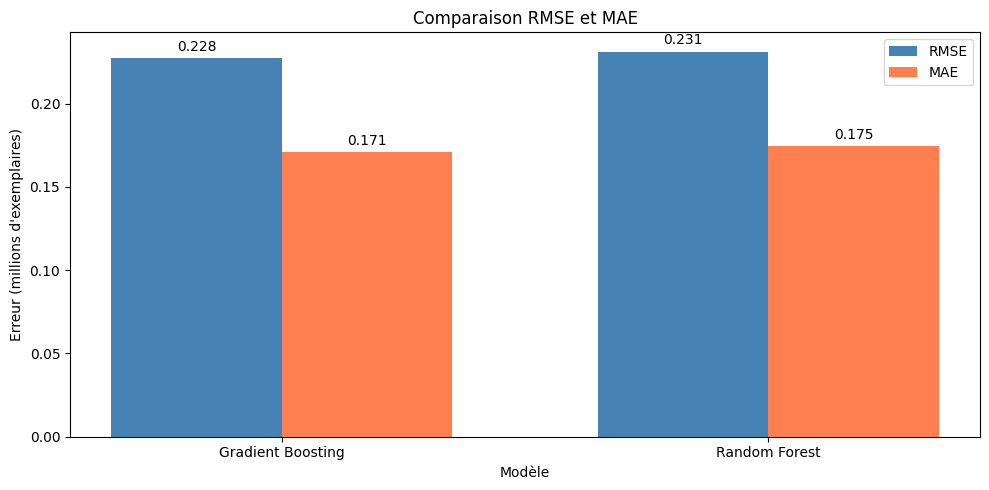

In [69]:
modeles = df_resultats['Modèle'].values
x = np.arange(len(modeles))
largeur = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
barres_rmse = ax.bar(x - largeur/2, df_resultats['RMSE (M)'], largeur, label='RMSE', color='steelblue')
barres_mae  = ax.bar(x + largeur/2, df_resultats['MAE (M)'],  largeur, label='MAE',  color='coral')

ax.set_xlabel('Modèle')
ax.set_ylabel('Erreur (millions d\'exemplaires)')
ax.set_title('Comparaison RMSE et MAE')
ax.set_xticks(x)
ax.set_xticklabels(modeles)
ax.legend()
ax.bar_label(barres_rmse, fmt='%.3f', padding=3)
ax.bar_label(barres_mae,  fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

### Analyse de la comparaison du RMSE et MAE

Ici, les résultats sont très proches entre les deux modèles. Gradient Boosting obtient les meilleurs scores avec un RMSE de 0.228 et un MAE de 0.171, suivi de Random Forest avec un RMSE de 0.231 et un MAE de 0.175.

Cependant, on remarque que les valeurs des RMSE et MAE ont beaucoup diminué en comparaison avec le dataset complet :
- Gradient Boosting est passé de RMSE = 0.755 à RMSE = 0.228 et MAE = 0.546 à MAE= 0.171
- Random Forest est passé de RMSE = 0.757 à RMSE = 0.231 et MAE = 0.547 à MAE=0.175

Cette diminution s'explique peut-être par le nombre de ventes maximales qui a diminué en comparaison avec le dataset complet (1,04M ici contre 3.8M pour le dataset complet). Cela ne veut pas forcément dire que les modèles sont meilleurs. En effet, 0.228 c'est 22% environ de 1.04, donc les deux modèles se trompent en moyenne de 22% de la plage totale. Pour un dataset de cette taille et de cette hétérogénéité, ce résultat reste acceptable.

Nous pouvons également remarquer une absence de valeurs aberrantes. En effet, l'écart RMSE/MAE de Gradient Boosting et de Random Forest est de 0,026M, ce qui est faible par rapport à la plage de ventes (0-1,04M). Ce n'était pas le cas avec les deux derniers filtrages.

**Cette fois-ci, on remarque que le RMSE et la MAE sont bien plus faibles avec cette version du dataset. Ainsi, nos modèles de prédictions marchent le mieux pour les jeux qui sont dans la norme, c'est-à-dire les jeux à faibles ventes (en dessous de 1.04M), qui constituent la majorité du dataset.**

## Comparaison des R²

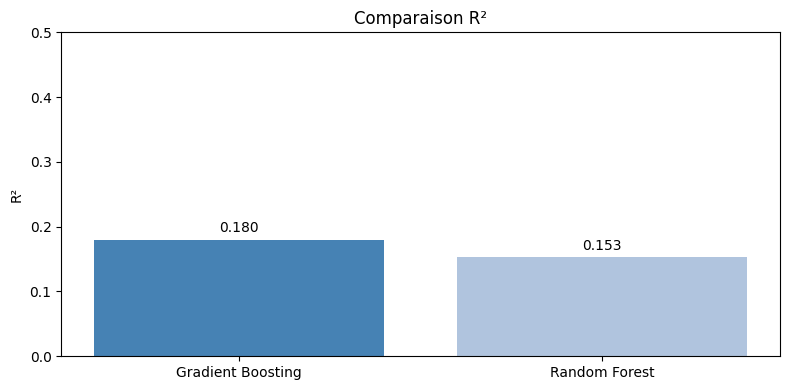

In [70]:
fig, ax = plt.subplots(figsize=(8, 4))
couleurs = ['steelblue' if r == df_resultats['R²'].max() else 'lightsteelblue' for r in df_resultats['R²']]
barres = ax.bar(modeles, df_resultats['R²'], color=couleurs)
ax.set_ylabel('R²')
ax.set_title('Comparaison R²')
ax.set_ylim(0, 0.5)
ax.bar_label(barres, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

### Analyse de la comparaison des R²

Pour la dernière comparaison des R², Gradient Boostong est encore devant avec R² = 0.180, suivi de Random Forest (R² = 0.153). On remarque une baisse du R² pour chaque modèle :
- Gradient Boosting est passé de R² = 0.248 (score dataset complet) à R² = 0.180
- Random Forest est passé de R² = 0.245 (score dataset complet) à R² = 0.153

Les performances restent globalement faibles. Malgré l'aménagement des données, près de 80% de la variance des ventes reste inexpliqué, confirmant que les features actuelles sont insuffisantes pour modéliser efficacement les facteurs de succès commercial des jeux vidéo.

## Valeurs réelles vs prédites

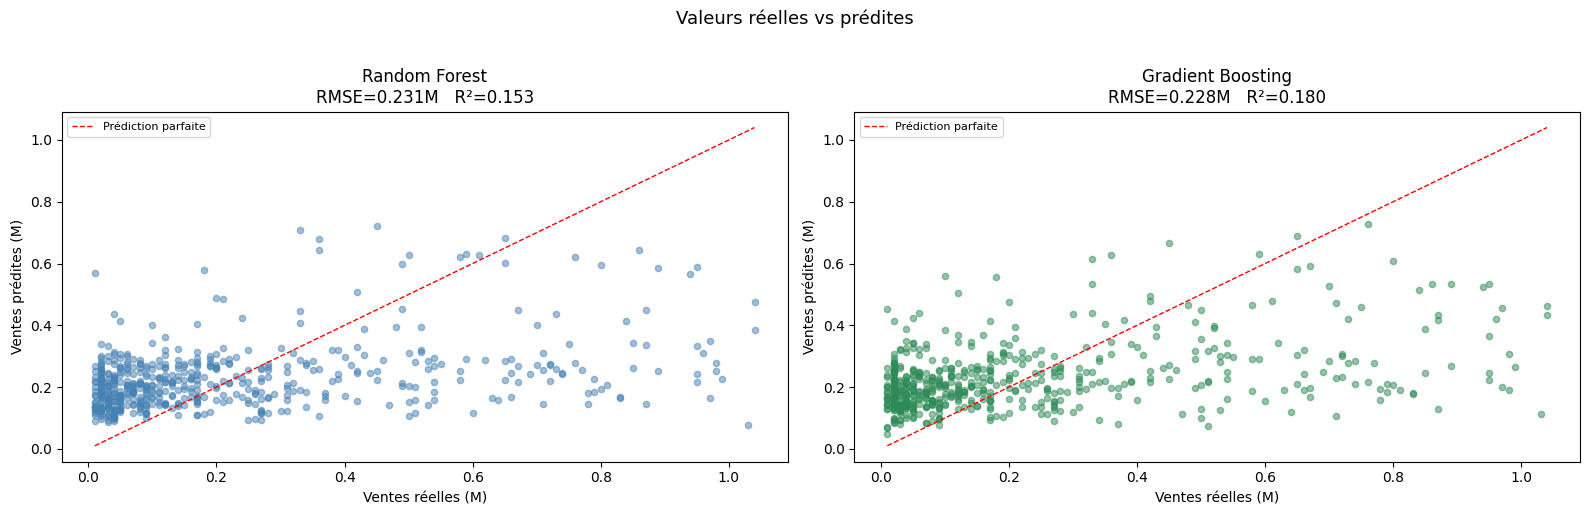

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

donnees = [
    ('Random Forest', y_true, y_pred_rf, rmse_rf, r2_rf, 'steelblue'),
    ('Gradient Boosting', y_true, y_pred_gb, rmse_gb, r2_gb, 'seagreen')
]

for ax, (nom, y_true, y_pred, rmse, r2, couleur) in zip(axes, donnees):
    ax.scatter(y_true, y_pred, alpha=0.5, color=couleur, s=20)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1, label='Prédiction parfaite')
    ax.set_title(f'{nom}\nRMSE={rmse:.3f}M   R²={r2:.3f}')
    ax.set_xlabel('Ventes réelles (M)')
    ax.set_ylabel('Ventes prédites (M)')
    ax.legend(fontsize=8)

plt.suptitle('Valeurs réelles vs prédites', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Analyse de la comparaison des valeurs réelles vs prédites

- Random Forest :
Random Forest montre une surprédiction pour les très faibles ventes (0–0,2M). Au-delà de ce seuil, les points se dispersent en dessous de la diagonale, révélant une tendance à surestimer les ventes moyennes à élevées. Une dispersion importante traduit une faible fiabilité du modèle sur ces valeurs.

- Gradient Boosting :
Gradient Boosting affiche de meilleurs résultats (RMSE = 0,228, R² = 0,180). Cependant, on remarque les mêmes tendances que Random Forest pour la prédiction : une surestimation des ventes pour les ventes en desous de 0.2M et une sous estimation pour les plus grosse ventes.

**Pour conclure, Gradient Boosting est le meilleur des deux modèles avec le RMSE le plus faible (0,228M) et le R² le plus élevé (0,180). Les deux modèles restent néanmoins peu fiables.**

# Importance des variables dans nos prédictions
Pour calculer l'importance des variables, il faut que l'on entraîne chaque modèle sur tout le dataset

In [72]:
noms_variables = variables_explicatives  # liste des noms de colonnes

## Random Forest
Pour le modèle random forest, feature_importances_ est intégré pour calculer l'importance des varibales explicatives. Il calcule pour chaque variable combien de fois elle a été utilisée pour faire des coupures dans les arbres, et à quel point ces coupures ont réduit l'erreur ou non

In [73]:
rf_final = RandomForestRegressor(
    **best_params_rf,
    random_state     = 42,
    n_jobs           = -1
)
rf_final.fit(X, y)

importances_rf = pd.Series(rf_final.feature_importances_, index=noms_variables)
importances_rf = importances_rf.sort_values()

## Gradient Boosting
Ici aussi, feature_importances_ est intégré

In [74]:
gb_final = GradientBoostingRegressor(**best_params_gb, random_state=42)
gb_final.fit(X, y)

importances_gb = pd.Series(gb_final.feature_importances_, index=noms_variables)
importances_gb = importances_gb.sort_values()

## Graphiques

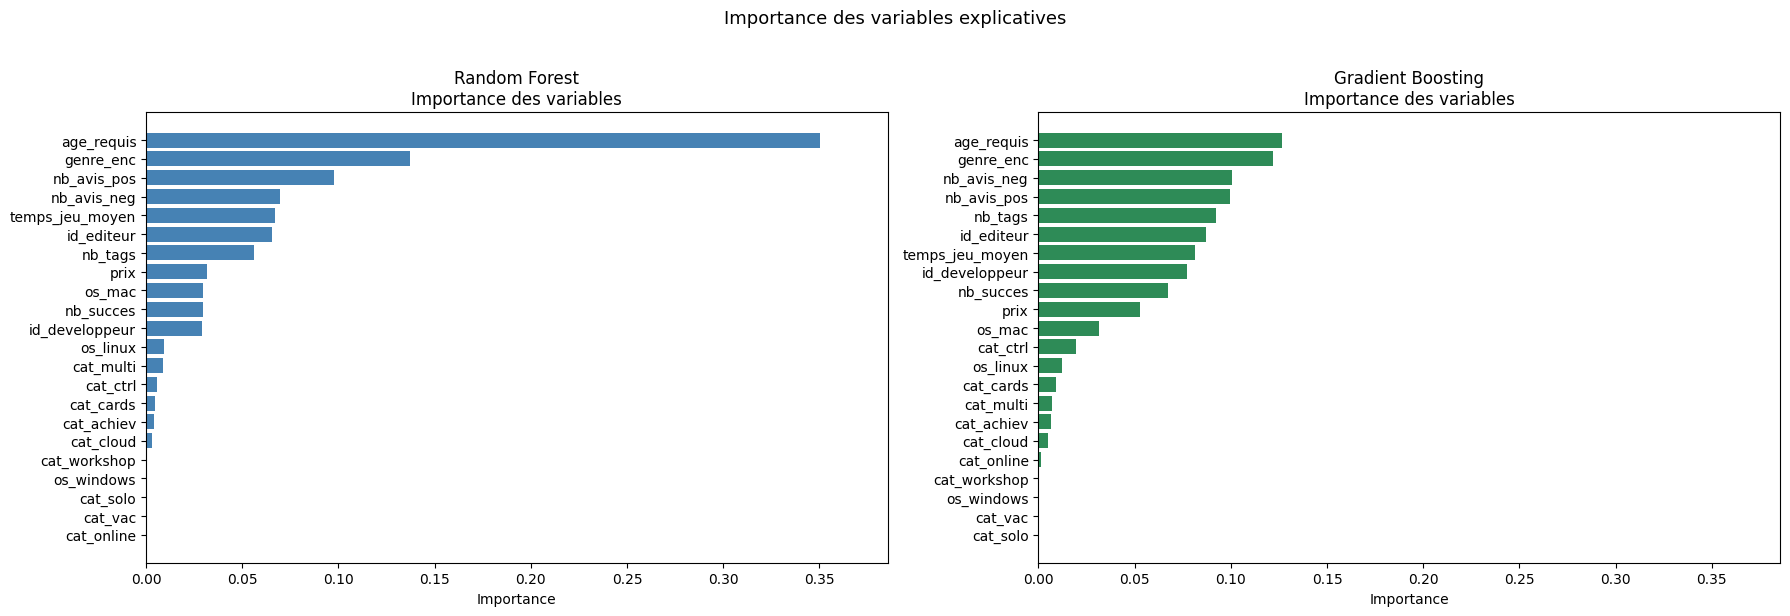

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Valeur max globale
max_importance = max(
    importances_rf.max(), 
    importances_gb.max(), 
)

# Random Forest
axes[0].barh(importances_rf.index, importances_rf.values, color='steelblue')
axes[0].set_title('Random Forest\nImportance des variables')
axes[0].set_xlabel('Importance')
axes[0].set_xlim(0, max_importance * 1.1)

# Gradient Boosting
axes[1].barh(importances_gb.index, importances_gb.values, color='seagreen')
axes[1].set_title('Gradient Boosting\nImportance des variables')
axes[1].set_xlabel('Importance')
axes[1].set_xlim(0, max_importance * 1.1)

plt.suptitle('Importance des variables explicatives', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Analyse des graphes sur l'importance des variables

**Analyse des valeurs d'importance globales**

Concernant les valeurs observées dans leur globalité, on remarque que la variable "nb_tags" n'est plus aussi bien classée qu'avant. Que ce soit avec le modèle Random Forest (passage de 1ère à 7ème place) ou Gradient Boosting (passage de 1ère à 5ème place), elle est devenue moins déterminante pour les modèles de prédiction sur ce sous-ensemble.

**Les 4 variables dominantes**
Cependant, les 4 variables les plus importantes pour nos deux modèles RF et GB restent : "age_requis", "genre_enc", "nb_avis_neg" et "nb_avis_pos", bien que leur ordre diffère légèrement entre les deux modèles.
On peut notamment voir que "age_requis" représente environ 35% de l'importance totale du modèle Random Forest, contre 13% pour Gradient Boosting. On remarque quand même une prépondérance marquée d'âge requis pour Random Forest (0.35 contre <0.14 pour les autres), tandis que Gradient Boosting est plus "doux", avec toutes les variables inférieures à 0.15.
Ainsi, ces 4 variables sont celles qui permettent le mieux d'expliquer les ventes d'un jeu avec moins de 0.5M de ventes.

**Variables secondaires et peu importantes**

Le genre arrive en 2ème place pour les deux modèles (0.14), confirmant son importance majeure. Les avis sont également importants (environ 0.1). En revanche, les nombres de tags sont beaucoup moins importants qu'avec les autres filtrages de dataset (0.09 pour RF et 0.1 pour GB). Peut-être que ce type de jeu a simplement moins de tags sur Steam ?
On remarque également que les développeurs et éditeurs sont bien moins importants pour ces jeux que pour les jeux vidéos faisant plus de ventes. Le prix est également peu important (0.05). On peut imaginer que ce sont des jeux à faible prix, ce qui expliquerait cette faible importance.

Enfin, les systèmes d'exploitation et les catégories (workshop, solo, vac...) restent toujours pas importants.

# Conclusion

**Dataset complet :**
- R² : GB=0.248 | RF=0.245 Meilleur : **GB**
- RMSE : GB=0.755 | RF=0.757 Meilleur : **GB**
- MAE : GB=0.546 | RF=0.547 Meilleur : **GB**

**Jeux moyens :**
- R² : GB=0.190 | RF=0.206 Meilleur : **RF**
- RMSE : GB=0.838 | RF=0.830 Meilleur : **RF**
- MAE : GB=0.661 | RF=0.667 Meilleur : **GB**

**Petits jeux :**
- R² : GB=0.180 | RF=0.153 Meilleur : **GB**
- RMSE : GB=0.227 | RF=0.231 Meilleur : **GB**
- MAE : GB=0.171 | RF=0.174 Meilleur : **GB**

Gradient Boosting dépasse Random Forest sur 7/9 métriques.

**Conclusion :**
Gradient Boosting **domine ou égale Random Forest partout** et offre les **meilleures prédictions** malgré des R² faibles (max 24%, moyenne environ 20%). Gradient Boosting est alors le meilleur choix pour prédire les ventes de jeu parmi ces deux modèles, bien que pas assez fonctionnel pour réellement le déployer.

Au niveau des types de modèles pour les différents types de jeux vidéos, le rapport entre RMSE et la plage des valeurs de ventes, nous avons trouvé 20% pour les jeux en général, contre environ 22% pour les jeux "moyens" et les "petits jeux".
Le meilleur type de modèle serait donc les modèles entraînés sur le dataset presque complet (valeurs extrêmes retirées). Le second meilleur type de modèle est le modèle des petits jeux, suivi des modèles des jeux moyens.  